# This is a minimal solve_ivp example of the Pandya+22 "sapphire" SAM
### This project is a work in progress.
### Do not publicly share without permission from Viraj Pandya (vgp2108@columbia.edu)

In [1]:
# load modules
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15, FlatLambdaCDM
from astropy.table import Table, join
from astropy import constants as const
from astropy import units as u
from astropy.io import fits
from scipy.interpolate import RegularGridInterpolator, UnivariateSpline, InterpolatedUnivariateSpline, interp2d, RectBivariateSpline
from scipy.ndimage import gaussian_filter1d
from glob import glob
import multiprocess
from scipy.integrate import simps, solve_ivp, trapz
import h5py 
from timeit import default_timer as timer
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import symlib # for this you just do "pip install symlib" 
# from sparta import moria # for this, you clone his bitbucket repo, go into analysis directory, and then "python setup.py install" 

plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

# read observed MW satellite data

In [2]:
# read in latest McConnachie+12 compilation from website 

hdu = fits.open('NearbyGalaxies_Jan2021_PUBLIC.fits')
tm12 = Table(hdu[1].data)
hdu.close()
tm12

GalaxyName,RA,Dec,EB-V,dmod,dmod+,dmod-,vh,vh+,vh-,Vmag,Vmag+,Vmag-,PA,PA+,PA-,e=1-b/a,e+,e-,muVo,muVo+,muVo-,rh,rh+,rh-,sigma_s,sigma_s+,sigma_s-,vrot_s,vrot_s+,vrot_s-,MHI,sigma_g,sigma_g+,sigma_g-,vrot_g,vrot_g+,vrot_g-,[Fe/H],feh+,feh-,F,pmra,epmra+,epmra-,pmdec,epmdec+,epmdec-,References
str16,str10,str11,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,str53
*Bootes3,13:57:12.0,26:48:0.0,0.021,18.35,0.1,0.1,197.5,3.8,3.8,12.6,0.5,0.5,90.0,999.0,999.0,0.5,999.0,999.0,31.3,0.3,0.3,999.0,999.0,999.0,14.0,3.2,3.2,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.1,0.2,0.2,2,nan,nan,nan,nan,nan,nan,(14)(15)(99)
*CanisMajor,7:12:35.0,-27:40:0.0,0.264,14.29,0.3,0.3,87.0,4.0,4.0,-0.1,0.8,0.8,123.0,999.0,999.0,999.0,999.0,999.0,24.0,0.6,0.6,999.0,999.0,999.0,20.0,3.0,3.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-0.5,0.2,0.2,4,nan,nan,nan,nan,nan,nan,(1)(2)(95)(176)
*Cetus2,1:17:52.8,-17:25:12.0,0.02,17.1,0.1,0.1,999.0,999.0,999.0,17.4,0.7,0.7,999.0,999.0,999.0,999.0,999.0,999.0,28.55,1.2,1.2,1.9,1.0,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.28,0.07,0.07,5,2.84,0.05,0.07,0.46,0.06,0.07,(232)(260)(266)(267)
*Columba1,5:31:26.4,-28:1:48.0,0.025,21.3,0.22,0.22,153.7,5.0,4.8,16.8,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,27.95,0.7,0.7,1.9,0.5,0.4,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,0.19,0.06,0.06,-0.36,0.06,0.06,(232)(248)(266)(267)
*Draco2,15:52:47.6,64:33:55.0,0.018,16.67,0.05,0.05,-342.5,1.1,1.2,14.0,0.8,0.8,76.0,22.0,32.0,0.23,0.15,0.15,25.62,1.3,1.3,3.0,0.7,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.7,0.1,0.1,5,1.08,0.07,0.07,0.91,0.08,0.08,(225)(259)(266)(267)
*Eridanus3,2:22:45.5,-52:17:1.0,0.025,19.7,0.2,0.2,999.0,999.0,999.0,17.33,0.86,0.86,62.0,11.0,11.0,0.32,0.13,0.13,22.84,4.28,2.13,0.29,0.23,0.23,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,1.08,0.14,0.45,-0.49,0.17,0.13,(226)(227)(255)(266)(267)
*Grus1,22:56:42.4,-50:9:48.0,0.008,20.4,0.2,0.2,-140.5,2.4,1.6,16.93,0.59,0.59,11.0,32.0,32.0,0.54,0.26,0.26,26.86,1.77,1.35,2.08,0.87,0.87,9.8,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.42,0.55,0.42,2,0.07,0.05,0.05,-0.29,0.06,0.07,(226)(252)(255)(266)(267)
*Grus2,22:4:4.8,-46:26:24.0,0.016,18.62,0.21,0.21,-110.0,0.5,0.5,14.7,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,28.35,0.7,0.7,6.0,0.9,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.51,0.11,0.11,3,0.38,0.03,0.03,-1.46,0.04,0.04,(232)(262)(266)(267)
*Horologium1,2:55:31.7,-54:7:8.0,0.014,19.5,0.2,0.2,112.8,2.5,2.6,15.95,0.56,0.56,50.0,26.0,26.0,0.31,0.16,0.16,26.28,1.1,0.99,1.54,0.34,0.34,4.9,2.8,0.9,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.76,0.1,0.1,2,0.82,0.03,0.03,-0.61,0.03,0.03,(226)(227)(254)(255)(266)(267)


In [3]:
# remove the two galaxies without Vmag
tm12 = tm12[tm12['Vmag']!=999]

# following his paper, use distance modulus to convert apparent Vmag to absolute M_V
tm12['M_V'] = tm12['Vmag'] - tm12['dmod']

# convert absolute magnitude to solar luminosities assuming solar M_V=4.83
tm12['L_V'] = 10**((tm12['M_V'] - 4.83)/(-2.5)) # Lsun

# his stellar mass in Table 4 assumes M/L=1 so kind of meaningless... but let's assume it since old stellar pop would have M/L~2 (Simon19)
tm12['Mstar'] = 1.0 * tm12['L_V'] # Msun

# convert distance modulus to distance in kpc
tm12['distance'] = 1e-3 * 10**(1+tm12['dmod']/5.)

tm12['rratio_300'] = tm12['distance'] / 300 
tm12['rratio_224'] = tm12['distance'] / 224 

# Alan McConnachie said via email that to select MW satellites, you just do distance < Rvir ~ 300 kpc (no vhelio cut as in his 2012 Figure 2)
# he also said that he will release another updated table by Dec 22, 2023
len(tm12), len(tm12[tm12['distance']<300]) # yeah about ~60 MW satellites makes sense


tm12

GalaxyName,RA,Dec,EB-V,dmod,dmod+,dmod-,vh,vh+,vh-,Vmag,Vmag+,Vmag-,PA,PA+,PA-,e=1-b/a,e+,e-,muVo,muVo+,muVo-,rh,rh+,rh-,sigma_s,sigma_s+,sigma_s-,vrot_s,vrot_s+,vrot_s-,MHI,sigma_g,sigma_g+,sigma_g-,vrot_g,vrot_g+,vrot_g-,[Fe/H],feh+,feh-,F,pmra,epmra+,epmra-,pmdec,epmdec+,epmdec-,References,M_V,L_V,Mstar,distance,rratio_300,rratio_224
str16,str10,str11,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,str53,float32,float32,float32,float32,float32,float32
*Bootes3,13:57:12.0,26:48:0.0,0.021,18.35,0.1,0.1,197.5,3.8,3.8,12.6,0.5,0.5,90.0,999.0,999.0,0.5,999.0,999.0,31.3,0.3,0.3,999.0,999.0,999.0,14.0,3.2,3.2,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.1,0.2,0.2,2,nan,nan,nan,nan,nan,nan,(14)(15)(99),-5.75,17060.818,17060.818,46.773525,0.15591174,0.20881037
*CanisMajor,7:12:35.0,-27:40:0.0,0.264,14.29,0.3,0.3,87.0,4.0,4.0,-0.1,0.8,0.8,123.0,999.0,999.0,999.0,999.0,999.0,24.0,0.6,0.6,999.0,999.0,999.0,20.0,3.0,3.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-0.5,0.2,0.2,4,nan,nan,nan,nan,nan,nan,(1)(2)(95)(176),-14.39,48752924.0,48752924.0,7.2110763,0.024036922,0.032192305
*Cetus2,1:17:52.8,-17:25:12.0,0.02,17.1,0.1,0.1,999.0,999.0,999.0,17.4,0.7,0.7,999.0,999.0,999.0,999.0,999.0,999.0,28.55,1.2,1.2,1.9,1.0,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.28,0.07,0.07,5,2.84,0.05,0.07,0.46,0.06,0.07,(232)(260)(266)(267),0.29999924,64.86349,64.86349,26.302685,0.087675616,0.1174227
*Columba1,5:31:26.4,-28:1:48.0,0.025,21.3,0.22,0.22,153.7,5.0,4.8,16.8,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,27.95,0.7,0.7,1.9,0.5,0.4,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,0.19,0.06,0.06,-0.36,0.06,0.06,(232)(248)(266)(267),-4.5,5395.1045,5395.1045,181.96999,0.6065666,0.812366
*Draco2,15:52:47.6,64:33:55.0,0.018,16.67,0.05,0.05,-342.5,1.1,1.2,14.0,0.8,0.8,76.0,22.0,32.0,0.23,0.15,0.15,25.62,1.3,1.3,3.0,0.7,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.7,0.1,0.1,5,1.08,0.07,0.07,0.91,0.08,0.08,(225)(259)(266)(267),-2.67,1000.0,1000.0,21.57745,0.071924835,0.0963279
*Eridanus3,2:22:45.5,-52:17:1.0,0.025,19.7,0.2,0.2,999.0,999.0,999.0,17.33,0.86,0.86,62.0,11.0,11.0,0.32,0.13,0.13,22.84,4.28,2.13,0.29,0.23,0.23,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,1.08,0.14,0.45,-0.49,0.17,0.13,(226)(227)(255)(266)(267),-2.3700008,758.5782,758.5782,87.096375,0.29032126,0.3888231
*Grus1,22:56:42.4,-50:9:48.0,0.008,20.4,0.2,0.2,-140.5,2.4,1.6,16.93,0.59,0.59,11.0,32.0,32.0,0.54,0.26,0.26,26.86,1.77,1.35,2.08,0.87,0.87,9.8,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.42,0.55,0.42,2,0.07,0.05,0.05,-0.29,0.06,0.07,(226)(252)(255)(266)(267),-3.4699993,2089.2947,2089.2947,120.226425,0.40075475,0.5367251
*Grus2,22:4:4.8,-46:26:24.0,0.016,18.62,0.21,0.21,-110.0,0.5,0.5,14.7,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,28.35,0.7,0.7,6.0,0.9,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.51,0.11,0.11,3,0.38,0.03,0.03,-1.46,0.04,0.04,(232)(262)(266)(267),-3.920001,3162.2812,3162.2812,52.966343,0.17655447,0.23645689
*Horologium1,2:55:31.7,-54:7:8.0,0.014,19.5,0.2,0.2,112.8,2.5,2.6,15.95,0.56,0.56,50.0,26.0,26.0,0.31,0.16,0.16,26.28,1.1,0.99,1.54,0.34,0.34,4.9,2.8,0.9,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.76,0.1,0.1,2,0.82,0.03,0.03,-0.61,0.03,0.03,(226)(227)(254)(255)(266)(267),-3.5500002,2249.0547,2249.0547,79.432846,0.26477614,0.35461092


In [4]:
# read Drlica-Wagner Table 2 which lists all confirmed MW satellites combining McConnachie+12 with Simon+19

tdw20 =Table.read('drlicawagner20_MWsatellites.txt',format='mrt')

# restrict to confirmed/probable dwarfs by doing Class >= 3 as suggested in paper
tdw20 = tdw20[tdw20['Class']>=3]

tdw20

Name,Survey,Class,RAdeg,DEdeg,m-M,ah,l_e,e,D,r1/2,VMag,Ref
,,,deg,deg,mag,arcmin,,,kpc,pc,mag,
str17,str8,int64,float64,float64,float64,float64,str1,float64,int64,int64,float64,str6
Antlia II,--,4,143.8868,-36.7673,20.6,76.2,--,0.38,132,2301,-9.03,1
Aquarius II,PS1,4,338.4813,-9.3274,20.2,5.1,--,0.39,108,125,-4.4,2
Bootes I,PS1,4,210.02,14.5135,19.1,9.97,--,0.3,66,160,-6.02,3
Bootes II,PS1,4,209.5141,12.8553,18.1,3.17,--,0.25,42,33,-2.94,3
Bootes III,PS1,4,209.3,26.8,18.4,30.0,--,0.5,47,289,-5.75,4
Bootes IV,PS1,3,233.689,43.726,21.6,7.6,--,0.64,209,277,-4.53,5
Canes Venatici I,PS1,4,202.0091,33.5521,21.7,7.12,--,0.44,218,338,-8.8,3
Canes Venatici II,PS1,4,194.2927,34.3226,21.0,1.52,--,0.4,160,55,-5.17,3


In [5]:
# convert absolute Vmag to L_V and then Mstar assuming stellar pop has M/L=1
tdw20['L_V'] = 10**((tdw20['VMag'] - 4.83)/(-2.5)) # Lsun
tdw20['Mstar'] = 1.0 * tdw20['L_V'] # Msun

In [6]:
# annoying manual dict mapping Drlica-Wagner+20 name to McConnachie+12 to get Fe/H
# i dont feel like coming up with a clever way to do this right now -- alan will get back to me via email about selecting MW sats from his 

map_name = {'Antlia II':'Antlia2         ', 'Aquarius II':'Aquarius2       ', 
            'Bootes I':'Bootes(1)       ', 'Bootes II':'Bootes2         ', 'Bootes III':'*Bootes3        ',
            'Bootes IV':'Bootes4         ', 'Canes Venatici I':'CanesVenatici(1)', 'Canes Venatici II':'CanesVenatici2  ', 'Carina':'Carina          ',
            'Carina II':'Carina2         ', 'Carina III':'Carina3         ', 'Centaurus I':'Centaurus1      ', 'Cetus II':'*Cetus2         ', 
            'Cetus III':'Cetus3          ','Columba I':'*Columba1       ', 'Coma Berenices':'ComaBerenices   ', 'Crater II':'Crater2         ',
            'Draco':'Draco           ', 'Draco II':'*Draco2         ','Eridanus II':'Eridanus2       ', 'Fornax':'Fornax          ',
            'Grus I':'*Grus1          ', 'Grus II':'*Grus2          ', 'Hercules':'Hercules        ','Horologium I':'*Horologium1    ',
            'Horologium II':'*Horologium2    ', 'Hydra II':'Hydra2          ', 'Hydrus I':'Hydrus1         ', 'LMC':'LMC             ',
            'Leo I':'Leo1            ', 'Leo II':'Leo2            ', 'Leo IV':'Leo4            ', 'Leo V':'Leo5            ', 
            'Pegasus III':'*Pegasus3       ', 'Phoenix II':'*Phoenix2       ',
            'Pictor I':'*Pictor1        ', 'Pictor II':'Pictor2         ', 'Pisces II':'Pisces2         ', 'Reticulum II':'*Reticulum2     ',
            'Reticulum III':'*Reticulum3     ', 'Sagittarius':'SagittariusdSph ', 'Sagittarius II':'*Sagittarius2   ', 'Sculptor':'Sculptor        ',
            'Segue 1':'Segue(1)        ', 'Segue 2':'Segue2          ', 'Sextans':'Sextans(1)      ', 'SMC':'SMC             ', 
            'Triangulum II':'*Triangulum2    ','Tucana II':'Tucana2         ', 'Tucana III':'*Tucana3        ', 'Tucana IV':'*Tucana4        ',
            'Tucana V':'*Tucana5        ', 'Ursa Major I':'UrsaMajor(1)    ','Ursa Major II':'UrsaMajor2      ',
            'Ursa Minor':'UrsaMinor       ', 'Virgo I':'Virgo1          ', 'Willman 1':'Willman1        '}

# now get Fe/H from McConnachie+12 table for all MW sats in Drlica-Wagner+20 table
FeH_m12 = np.array([tm12[tm12['GalaxyName']==map_name[name]]['[Fe/H]'][0] for name in tdw20['Name']])
FeH_err_high = np.array([tm12[tm12['GalaxyName']==map_name[name]]['feh+'][0] for name in tdw20['Name']])
FeH_err_low = np.array([tm12[tm12['GalaxyName']==map_name[name]]['feh-'][0] for name in tdw20['Name']])

tdw20['Fe/H'] = FeH_m12
tdw20['Fe/H_err_high'] = FeH_err_high
tdw20['Fe/H_err_low'] = FeH_err_low

# read Local Group HI data

Code snippets taken from ../data/observations/putman21_lg_dwarfs/lg_dwarf_reader.ipynb courtesy of Jingyao Zhu. See https://iopscience.iop.org/article/10.3847/1538-4357/abe391 for more details.

In [7]:
data_dir= '../data/observations/' #  '../paper_data/'

# local group dwarf galaxy data from Mary's 2021 paper
# all dwarf galaxies within 2 Mpc of the Milky Way, stellar data from McConnachie, HI gas data newly compiled

data_P21_dir = data_dir + 'putman21_lg_dwarfs/' # read in the data files from your local directory

# the relevant table for LG dwarf orbits is table 3
putman_dwarf_orbit_tbl = Table.read(data_P21_dir + 'table3.dat',
                                    readme=data_P21_dir + 'ReadMe',
                                    format='ascii')

# table 1: HI masses (including upper limits etc) and coordinates
# table 1 quick view: HI mass, coordinates and more
# the column l_MHI states whether it's HI mass or upper limit (< for upper limits)
# the upper limit dwarfs are typically considered gasless/quenched LG dwarfs
putman_dwarf_hi_coord_tbl = Table.read(data_P21_dir + 'table1.dat',
                                       readme=data_P21_dir + 'ReadMe',
                                       format='ascii')

# table 2: 
# stellar mass (in terms of V band luminosity, consistent with McConnachie12 updated)
# distances to the host, see DMW and DM31, whichever is closer means it's more associated with that host
# DLG is distance to some modeled local group boundary
putman_dwarf_stellar_tbl = Table.read(data_P21_dir + 'table2.dat',
                                       readme=data_P21_dir + 'ReadMe',
                                       format='ascii') 

# join both Tables for easy manipulation
putman21 = join(putman_dwarf_hi_coord_tbl, putman_dwarf_stellar_tbl, keys='Name')

In [8]:
# values from Putman+21 
Rvir_MW = 224.
Rvir_M31 = 266.

# catagorize dwarves if they are in Rvir of MW or M31 
putman21['in_MW'] = putman21['DMW'] <= Rvir_MW
putman21['in_M31'] = putman21['DM31'] <= Rvir_M31

# we can calculate the ratio d_sub / Rvir_host for the dwarves 
putman21['rratio'] = -1.
putman21['rratio'][putman21['in_MW']] = putman21['DMW'][putman21['in_MW']] / Rvir_MW 
putman21['rratio'][putman21['in_M31']] = putman21['DM31'][putman21['in_M31']] / Rvir_M31 

# Msun, assume ratio of M/L = 1 like above since it is also McConnachie 
putman21['Mstar'] = 1.0 * putman21['Lv'] 

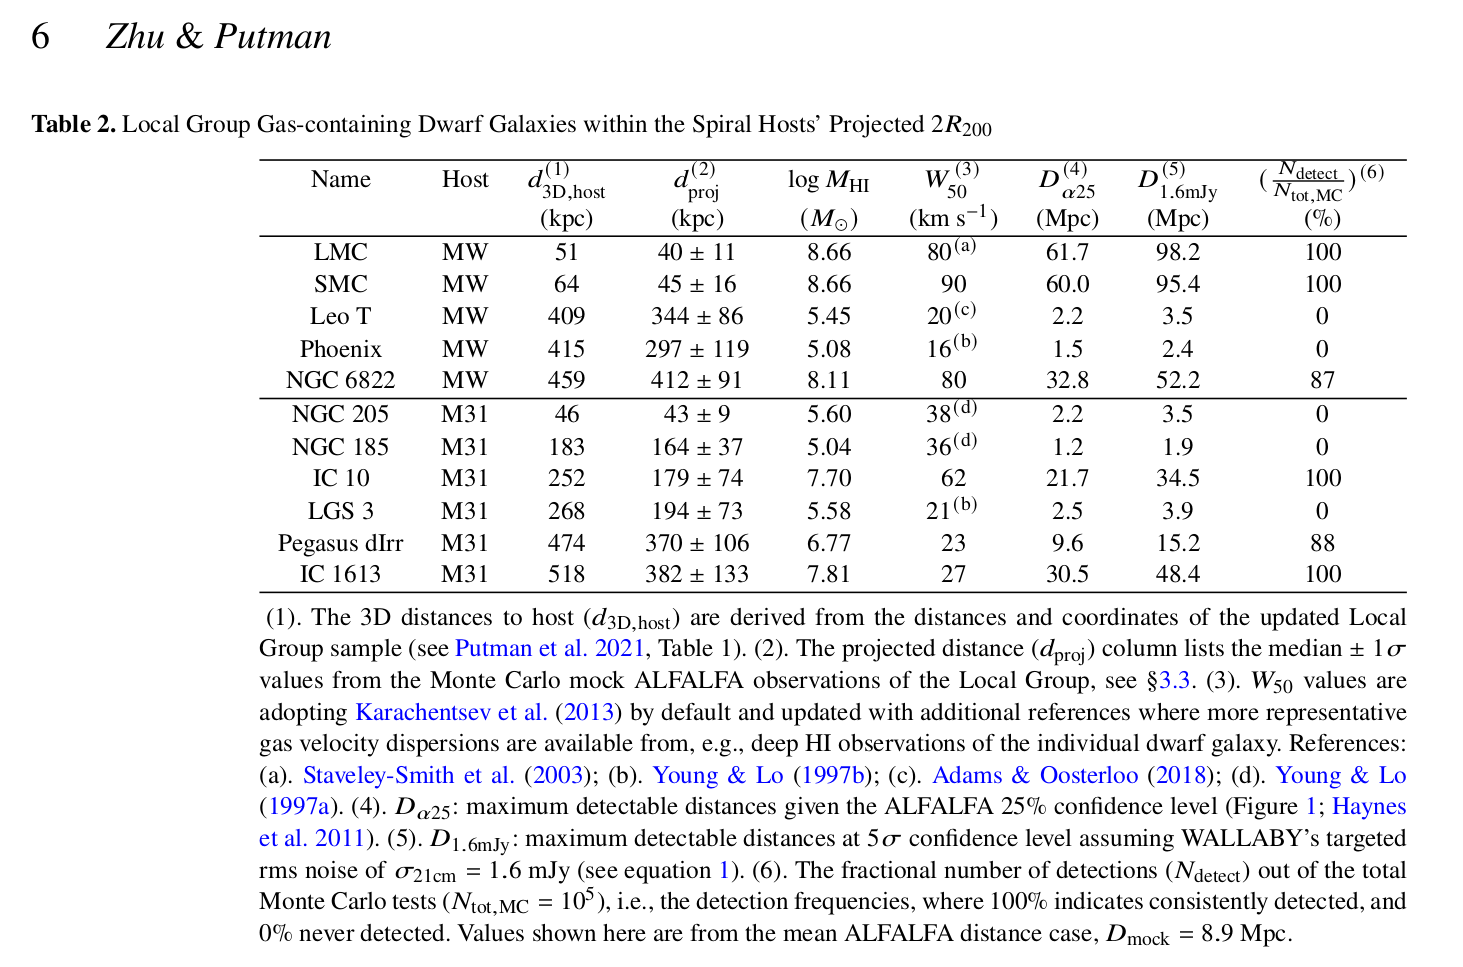

In [9]:
# there are not many gaseous sats within MW or M31's Rvir (2Rvir) radii
# the few ones with gas within their hosts' projected 2R200 (in our mock Local Group observations) are attached 

from IPython.display import Image
Image(filename=data_P21_dir + 'lg_2rvir_gaseous_sats.png') 

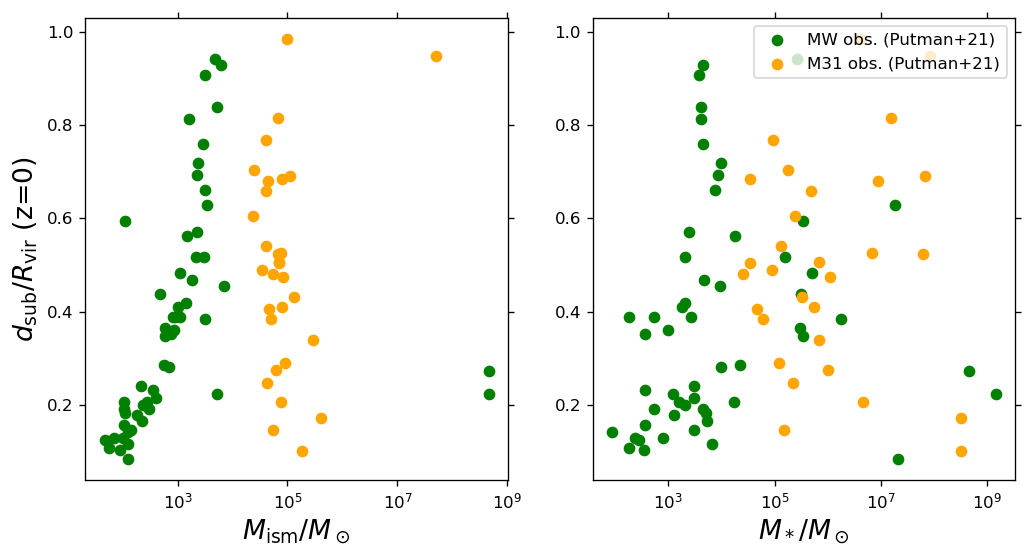

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(putman21['MHI'][putman21['in_MW']].astype('float'), putman21['rratio'][putman21['in_MW']], c='green', label='MW obs. (Putman+21)')
axes[0].scatter(putman21['MHI'][putman21['in_M31']].astype('float'), putman21['rratio'][putman21['in_M31']], c='orange', label='M31 obs. (Putman+21)')
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$M_{\rm ism} / M_\odot$', fontsize=16)
axes[0].set_ylabel(r'$d_{\rm sub}/R_{\rm vir}$ (z=0)',fontsize=16)

axes[1].scatter(putman21['Mstar'][putman21['in_MW']].astype('float'), putman21['rratio'][putman21['in_MW']], c='green', label='MW obs. (Putman+21)')
axes[1].scatter(putman21['Mstar'][putman21['in_M31']].astype('float'), putman21['rratio'][putman21['in_M31']], c='orange', label='M31 obs. (Putman+21)')
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$M_{\rm *} / M_\odot$', fontsize=16)
axes[1].legend()

# download Symphony data -- should take only a few min and it's < 1 GB

these are not full tree files but much more convenient and compact 2D arrays where 0th row = main branch properties of host MW halo, nth row = main branch properties of nth subhalo (ordering of subhalo into rows is based on decreasing Mpeak)

http://web.stanford.edu/group/gfc/symphony/build/html/getting_started.html

In [11]:
base_dir = '/Users/austen/data/symphony/'

In [12]:
# symlib.download_files('guest', '$YmPh0ny', "SymphonyMilkyWay", None, base_dir, target='halos')

# print('Finished!')

# read Symphony data

In [13]:
suite_name = 'SymphonyMilkyWay'
n_hosts = symlib.n_hosts('SymphonyMilkyWay')

i_host = 12

sim_dir = symlib.get_host_directory(base_dir,'SymphonyMilkyWay', i_host)
print(n_hosts, sim_dir)

params = symlib.simulation_parameters(sim_dir)
print(params)

# set up astropy cosmology object with same parameters as simulation
cosmo = FlatLambdaCDM(H0=params['H0'],Om0=params['Om0'],Ob0=params['Ob0'])
print(cosmo)

### read data
s, hist = symlib.read_symfind(sim_dir) # symfind subhalo finder
r, hist_r = symlib.read_rockstar(sim_dir) # rockstar halo finder

# scale factors corresponding to each snapshot of the simulation
scale = symlib.scale_factors(sim_dir)

# convert scale factors to cosmic age (time since BB)
time = cosmo.age(1/scale-1).value # Gyr

### test subhalo selection
isubs = [i for i in range(1,len(r)) if r[i,-1]['ok'] == True and r[i,-1]['m']/r[0,-1]['m'] > 2e-4 and np.sqrt(np.sum(r[i,-1]['x']**2)) <= r[0,-1]['rvir']]

# print number of selected subhalos, number of total subhalos, and most massive mpeak (LMC is logmpeak~11)
print(len(isubs), len(r), np.max(hist_r[isubs]['mpeak'])/1e11)

# repeat using symfind -- maybe it found extra z=0 surviving subhalos? 
isubs_s = [i for i in range(1,len(s)) if s[i,-1]['ok'] == True and s[i,-1]['m']/r[0,-1]['m'] > 2e-4 and np.sqrt(np.sum(s[i,-1]['x']**2)) <= r[0,-1]['rvir']]
print(len(isubs_s), len(s), np.max(hist[isubs_s]['mpeak'])/1e11)

45 /Users/austen/data/symphony/SymphonyMilkyWay/Halo414
{'flat': True, 'H0': 70.0, 'Om0': 0.286, 'Ob0': 0.049, 'sigma8': 0.82, 'ns': 0.95, 'eps': 0.17, 'mp': 281981.0, 'n_snap': 236, 'h100': 0.7}
FlatLambdaCDM(H0=70.0 km / (Mpc s), Om0=0.286, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.049)
41 439 1.7242857472
37 439 4.0857141248


In [14]:
### define constants and conversions 
const_mp = const.m_p.to('Msun').value 
cm_to_kpc = u.cm.to('kpc') # multiply something in cm by this to get to kpc 
kpc_to_cm = u.kpc.to('cm') # multiply something in kpc, it becomes units of cm
const_kB = const.k_B.to('erg/K').value # so that k*T = erg by default
yr_to_s = u.yr.to('s') # if you multiply something in yr by this, you get it in units of sec
s_to_yr = u.s.to('yr')
Msun_to_g = u.Msun.to('g') 
f_b = cosmo.Ob0 / cosmo.Om0 # ~15 %
G = const.G.to('cm**3 / (g * s**2)').value

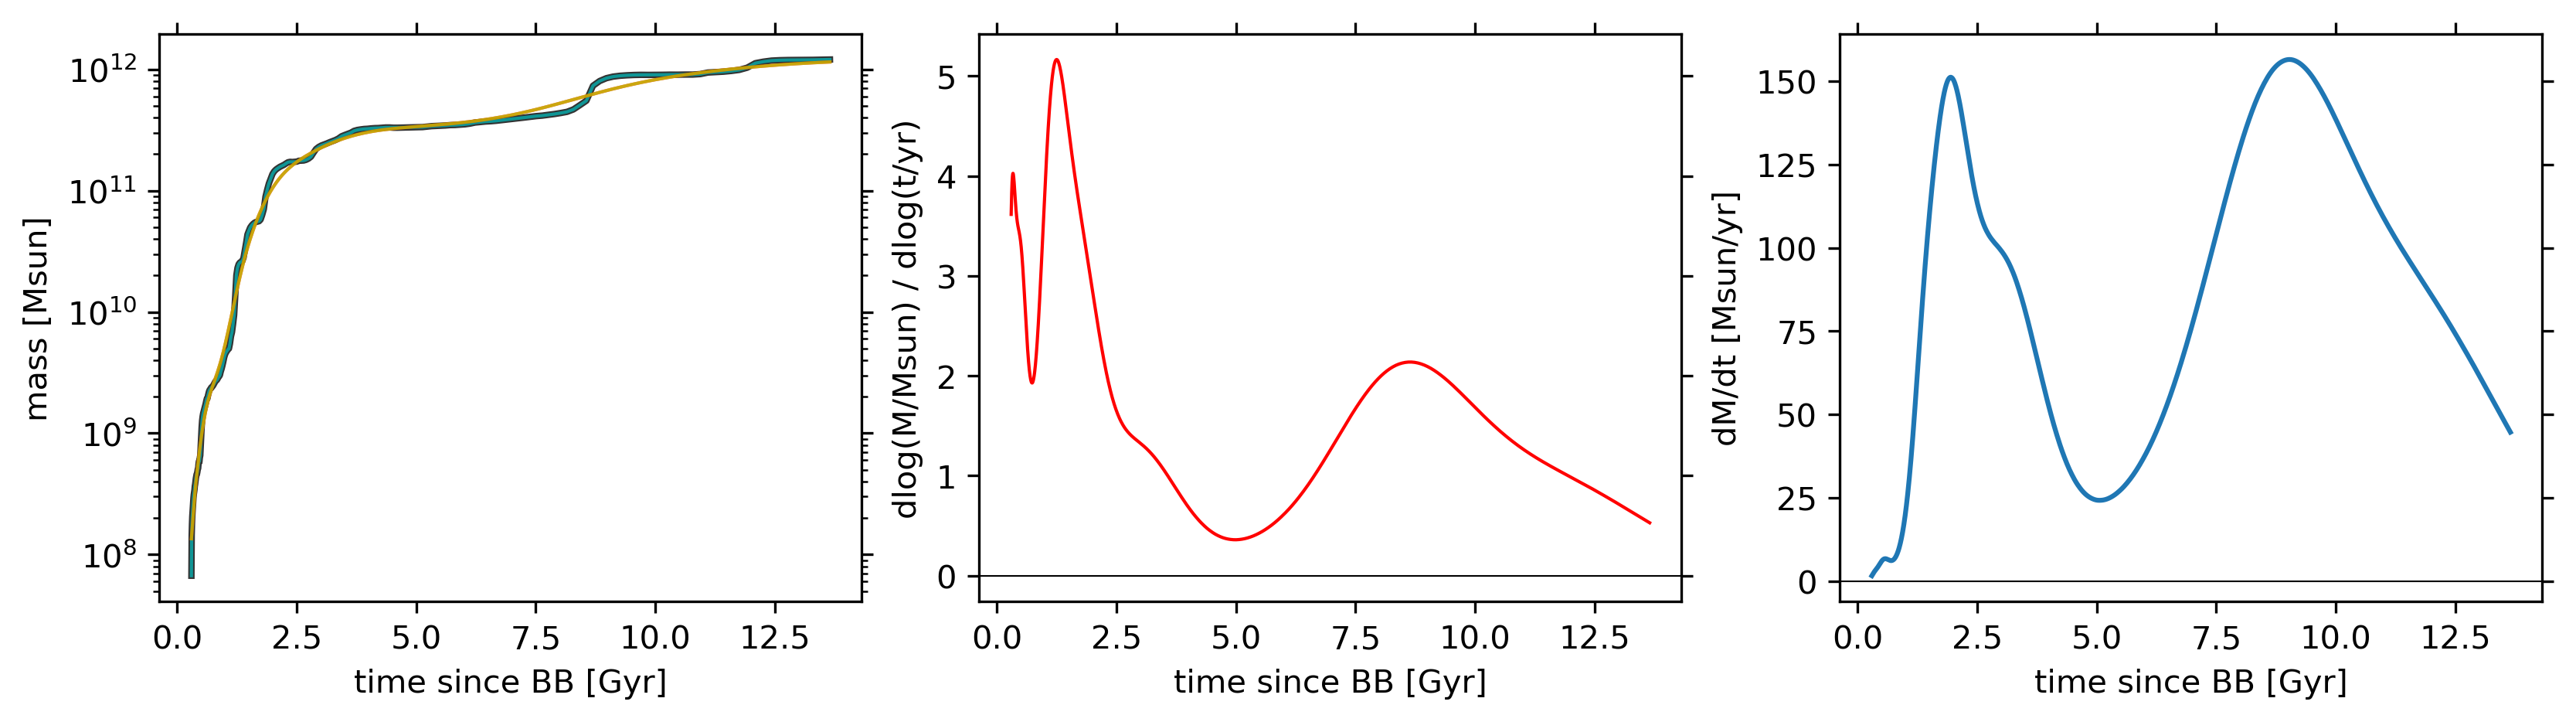

In [15]:
""" for host, convert Mvir(t) to Mpeak(<t), gaussian-smooth and interpolate to get dMpeak/dt """

# first get Mvir(t) from rockstar at snapshots where halo exists and has "ok" flag == True according to additional symlib sanity checks 
ok = r[0,:]["ok"] # 0th first index is for host 
Mvir = r[0,ok]["m"] # Mvir(t) from rockstar at snapshots where halo exists / is "ok" 

# at every snap, replace Mvir with Mpeak(<snap) with this list comprehension
Mpeak = [Mvir[0]] + [np.max(Mvir[:i+1]) for i in range(1,len(scale[ok]))]

# now apply a gaussian filter to ensure monotonicity and that dMpeak/dt cannot be negative 
Msmooth = 10**gaussian_filter1d(np.log10(Mpeak),10,mode='nearest')

# now fit cubic spline to log(M/Msun) vs log(t/yr)
time_yr = time*1e9 # Gyr to yr
interp_logMsmooth = InterpolatedUnivariateSpline(np.log(time_yr[ok]),np.log(Msmooth),k=3,ext=3)

# now take derivative of spline using its well-defined derivative function
# this is dlog(M/Msun)/dlog(t/yr) -- to convert to dM/dt in Msun/yr, you multiply by Mhalo(t)/t
interp_dlogM_dlogt = interp_logMsmooth.derivative()

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(11,3),constrained_layout=True,dpi=300)

interp_logt = np.linspace(np.log(time_yr[ok][0]),np.log(time_yr[ok][-1]),1000)

axes[0].plot(time[ok],r[0,ok]['m'],c='k',lw=2,alpha=0.8)
axes[0].plot(time[ok],Mpeak,c='c',lw=1,alpha=0.7)
axes[0].plot(time[ok],Msmooth,c='r',lw=1,alpha=0.7)
axes[0].plot(np.exp(interp_logt)*1e-9,np.exp(interp_logMsmooth(interp_logt)),'y-',alpha=0.8,lw=1)
axes[0].set_yscale('log')
axes[0].set_ylabel('mass [Msun]')

axes[1].plot(np.exp(interp_logt)*1e-9,interp_dlogM_dlogt(interp_logt),'r-',lw=1)
axes[1].axhline(0,color='k',lw=0.5) # note how the savitzky-golay version can end up with negative dM/dt for window_length same as sigma of gaussian_filter1d
axes[1].set_ylabel('dlog(M/Msun) / dlog(t/yr)')

### convert dlogM/dlogt to Msun/yr by multiplying by M(t)/t
axes[2].plot(np.exp(interp_logt)*1e-9,interp_dlogM_dlogt(interp_logt)*np.exp(interp_logMsmooth(interp_logt))/(np.exp(interp_logt)))
axes[2].axhline(0,color='k',lw=0.5)
axes[2].set_ylabel('dM/dt [Msun/yr]')

for ax in axes:
    ax.set_xlabel('time since BB [Gyr]')

In [1322]:
""" other host halo interpolators that I need """

# faster to interpolate than do cosmology root-finding calculation; ext=3 means return boundary values at ends
interp_redshift = InterpolatedUnivariateSpline(time,1/scale-1,k=3,ext=3) # this can be done at all times regardless of "ok"

interp_logRvir = InterpolatedUnivariateSpline(time[ok],gaussian_filter1d(np.log(r[0,ok]['rvir']),10,mode='nearest'),k=3,ext=3) # proper kpc

Vvir_rockstar = np.sqrt(const.G * r[0,ok]['m']*u.Msun / (r[0,ok]['rvir']*u.kpc)).to('km/s').value # km/s
interp_logVvir = InterpolatedUnivariateSpline(time[ok],gaussian_filter1d(np.log(Vvir_rockstar),10,mode='nearest'),k=3,ext=3)

interp_logcNFW = InterpolatedUnivariateSpline(time[ok],gaussian_filter1d(np.log(r[0,ok]['cvir']),10,mode='nearest'),k=3,ext=3) # dimensionless

interp_rsub_savgolay = InterpolatedUnivariateSpline(time[ok],savgol_filter(99*np.ones(r[0,ok].shape[0]) ,window_length=5,polyorder=4),k=3,ext=3) # proper kpc


In [1323]:
###### UV background suppression of fb*Mdot_vir (relevant for m10 halos)

# First compute the "Filtering Mass" at which halos accrete only half of the incoming baryon fraction fb*Mdot_vir (Gnedin+00)
# The following is basically copied from Rachel's SAM code (module = stars.cc)
# This is the analytic model from Appendix B of Kravtsov+04

def m_filt(z, z_overlap=9.0, z_reionize=3.5, z_squelch=8.0):
    # from Rachel's param.sample, follows Kravtsov+04 appendix B
    # z1=z_overlap, z2=z_reionize, z_squelch = when suppression ('squelching') turned on
    # Rachel tuned these parameters to reproduce Okamoto+08, so do not over-interpret parameter names or modify values
    # NOTE: I should probably re-write this so the parameters reflect their intended meaning (eg z_reionize >> 3.5)
    
    a_o = 1.0/(1+z_overlap) # scale factor where multiple HII regions BEGIN TO overlap
    a_r = 1.0/(1+z_reionize) # scale factor of complete reionization
    a = 1.0 / (1+z) # current scale factor
    
    # Jeans mass in Msun; 0.59 is mean molecular weight
    m_jeans = 2.5E11 * cosmo.h**-1 * np.sqrt(cosmo.Om0)**-1 * (0.59)**-1.5 
    
    alpha = 6.0 # power that controls growth rate of UV background flux (Kravtsov+04 fixed alpha=6)
    
    if a < a_o:
        f_a = (3.0 * a / ((2.0+alpha)*(5.0+2.0*alpha))) * (a/a_o)**alpha
    elif a >= a_o and a <= a_r: 
        f_a = (3.0/a)*a_o**2*(1.0/(2+alpha) - (2*(a/a_o)**-0.5)/(5+2*alpha)) + a**2/10. - (a_o**2/10.)*(5-4*(a/a_o)**-0.5)
    elif a > a_r: 
        f1 = a_o**2*(1/(2+alpha) - 2*(a/a_o)**-0.5/(5+2*alpha))
        f2 = a_r**2/10.*(5-4*(a/a_r)**-0.5)
        f3 = a_o**2/10.*(5-4*(a/a_o)**-0.5)
        f4 = a*a_r/3. - a_r**2/3.*(3-2*(a/a_r)**-0.5)
        f_a = 3.0/a * (f1 + f2 - f3 + f4)
        
    mf = m_jeans * f_a**1.5
    
    # constant from Rachel's stars.cc implementation
    # this ensures Mfilt defined in this way matches the Okamoto+08 "M_characteristic" definition normalization
    Mfilt_factor = 0.0933 
    
    return Mfilt_factor * mf

# Next compute the actual suppression factor f_UV that depends on the filtering mass 
# Halos with Mvir >> Mfilt will have f_UV ~ 1 (no suppression), whereas much lower mass halos tend to f_UV ~ 0
# This is eqn (1) of Okamoto+08 who studied the UV background in hydro simulations
# NOTE: I should update this to use Faucher-Giguere+09 (or 18) to be consistent with FIRE
def collapse_fraction(m,mfilt):
    alpha = 2.0
    
    fcoll = (1+(2**(alpha/3.)-1.)*(m/mfilt)**-alpha)**(-3/alpha)
    
    return fcoll

In [1324]:
""" interpolate sutherland & dopita 93 CIE cooling function """

# read the cooling table
# rows = temperature, columns = gas metallicities log(Z/Zsun), units = erg cm^3 / s
tcool = Table.read('newcool.dat',format='ascii',
                   names=('logT','-99','-3','-2','-1.5','-1.0','-0.5','0.0','0.5',))
# first convert tcool astropy Table into a 2D numpy array (this is the most elegant, easiest way I found to do this)
# NOTE: I omitted logZ=-99 to make interpolation easier since logZ=-99 (metal-free) is similar to logZ=-3 (extremely metal-poor)
arr_coolfunc = tcool.to_pandas().to_numpy(dtype='float')[:,2:]
# set up the (logT, logZ) meshgrid corresponding to each point in the 2D cooling function array
logT_bins = np.asarray(tcool['logT'])
logZ_bins = np.array(tcool.colnames[2:],dtype='float')
logT_mesh, logZ_mesh = np.meshgrid(logT_bins, logZ_bins) # for scatter plot 

# create linear 2D interpolator function (use 'nearest neighbor' extrapolation outside input range)
coolfunc_sd93 = interp2d(logT_bins, logZ_bins, arr_coolfunc.T, kind='linear', fill_value=None) 

# this seems better behaved for pairs (logT,logZ)
rgi_sd93 = RegularGridInterpolator((logT_bins,logZ_bins),arr_coolfunc,method='nearest',bounds_error=False,fill_value=None)

### test evaluation for a given (logT, logZcgm)
coolfunc_sd93(6.0,-1.0),rgi_sd93((6.0,-1.0)) # Lambda in erg*cm**3/s for CGM that has T=1e6 K and Zcgm=0.1Zsun everywhere

/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/3931470229.py:16: DeprecationWarning: `interp2d` is deprecated!
`interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.12.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://gist.github.com/ev-br/8544371b40f414b7eaf3fe6217209bff`

  coolfunc_sd93 = interp2d(logT_bins, logZ_bins, arr_coolfunc.T, kind='linear', fill_value=None)
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/3931470229.py:22: DeprecationWarning:         `interp2d` is deprecated!
        `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.12.0.

        For legacy code, nearly bug-for-bug compatible replacements are
        `

(array([-22.59]), array(-22.59))

In [1325]:
"""
Fitting functions for free model parameters.
These are power laws where both the normalization and slope can depend on redshift.
The default values are motivated by Pandya+22 but they are designed to be varied. 
"""

def get_tdep(Vvir,redshift,A=3.0,alpha0=-3.0,alphaz=0.0,beta=-0.7): 
    """
    Returns ISM gas depletion time in Gyr for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope both can depend on redshift
    """
    alpha = alpha0 + alphaz*(1+redshift) 
    return A * (Vvir/125.)**alpha * (1+redshift)**beta

def get_etaM_ism(Vvir,redshift,A=1.0,alpha0=-3.7,alphaz=0.0,beta=2.4):
    """
    Returns ISM mass loading factor [dimensionless] for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope both can depend on redshift
    """    
    alpha = alpha0 + alphaz*(1+redshift)
    return A * (Vvir/125.)**alpha * (1+redshift)**beta

def get_etaE_ism(Vvir,redshift,A=0.1,alpha0=-0.5,alphaz=0.0,beta=0.0): # March 2023 -- this is not designed to be consistent with get_vB_ism
    """
    Returns ISM energy loading factor [dimensionless] for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope can both depend on redshift
    
    We don't want etaE to exceed 1 (which it might for certain slopes and normalizations) so we use np.minimum
    """
    alpha = alpha0 + alphaz*(1+redshift) 
    # hard check to see if float vs. array, so it works with both integrators right now
    if isinstance(Vvir, np.ndarray):
        etaE = A * (Vvir/125.)**alpha * (1+redshift)**beta 
        etaE[etaE > 1] = 1 
        return etaE 
    
    return np.min([A * (Vvir/125.)**alpha * (1+redshift)**beta, 1.0])


def get_etaZ_ism(Vvir,redshift,A=0.5,alpha0=0.0,alphaz=0.0,beta=0.0): # this is the Carr/Bryan approach for increasing Zwind > Zism 
    """
    Returns ISM metal loading factor [dimensionless] for halo with Vvir [km/s] and redshift [dimensionless] 
    Power law whose normalization and slope can both depend on redshift
    
    We don't want etaZ to exceed 1 (which it might for certain slopes and normalizations) so we use np.minimum
    """
    
    alpha = alpha0 + alphaz*(1+redshift)
    # hard check to see if float vs. array, so it works with both integrators right now
    if isinstance(Vvir, np.ndarray):
        etaZ = A * (Vvir/125.)**alpha * (1+redshift)**beta
        etaZ[etaZ > 1] = 1 
        return etaZ 

    return np.min([A * (Vvir/125.)**alpha * (1+redshift)**beta, 1.0]) 


def get_Zin_halo(Vvir,redshift,A=0.25,alpha0=2.2,alphaz=0.0,beta=-1.3):
    """
    Returns metal mass fraction of inflowing gas at Rvir for halo with Vvir [km/s] and redshift [dimensionless]
    Power law whose normalization and slope both can depend on redshift
    NOTE: we multiply the return value by 0.02 since the fiducial FIRE-2 calibrated parameters give Zin_halo in units of Zsun=0.02
    """      
    alpha = alpha0 + alphaz*(1+redshift)
    return 0.02 * A * (Vvir/125.)**alpha * (1+redshift)**beta

def get_fprev(Vvir,fmin=0.25,fmax=0.9641,fscale=-7.1348,fpivot=1.8775):
    """
    Returns halo gas accretion suppression factor [dimensionless] for halo with Vvir [km/s]
    Generalized logistic function
    """      
    return fmin + (fmax - fmin) / (1.0 + np.exp(fscale*(np.log10(Vvir) - fpivot)))    
    

In [1326]:
# density formula from viraj's paper 
def n0_r(n0, r, Rvir, alpha_n):
    return n0*(r / Rvir)**alpha_n

def T0_r(T0, r, Rvir, alpha_T):
    return T0*(r / Rvir)**alpha_n

# calculating CGM mass between two radii
def mCGM_r1_r2(n0, Rstart, Rend, alpha_n):
    Rstart = Rstart * kpc_to_cm
    Rend = Rend * kpc_to_cm
    
    return n0 * (4*np.pi *0.59*const_mp * (Rend**(3+alpha_n) - (Rstart)**(3+alpha_n))) / ((3+alpha_n)*Rend**(alpha_n) )

def analytic_n0(Mcgm, Rstart, Rvir, alpha_n):
    Rvir = Rvir * kpc_to_cm
    Rstart = Rstart * kpc_to_cm
    
    return (3+alpha_n)*Mcgm*Rvir**(alpha_n) / (4*np.pi * 0.59*const_mp * (Rvir**(3+alpha_n) - (Rstart)**(3+alpha_n))) # cm**-3

def Ecgm_r1_r2(T0, Rstart, Rend, n0, alpha_n, alpha_T):     
    Rstart = Rstart * kpc_to_cm
    Rend = Rend * kpc_to_cm
    
    return T0 * (6*np.pi*n0*const_kB*(Rend**(alpha_n+alpha_T+3)-(Rstart)**(alpha_n+alpha_T+3))) / ((alpha_n+alpha_T+3)*Rend**(alpha_n+alpha_T))

def analytic_T0(Ecgm, Rstart, Rvir, n0, alpha_n, alpha_T):
    Rvir = Rvir * kpc_to_cm
    T0_est = (alpha_n+alpha_T+3)*Rvir**(alpha_n+alpha_T) * Ecgm / (6*np.pi*n0*const_kB*(Rvir**(alpha_n+alpha_T+3)-(Rstart)**(alpha_n+alpha_T+3))) # K
    # return np.nan_to_num(T0_est,nan=1,posinf=1,neginf=1) # at early times when Mcgm=0, n0=0 so T0=nan; return 1K
    return T0_est

In [1330]:
"""
Set up the integrator function 
This should return the Mdot's at each timestep
"""

def integrator(logt, logy, parameters, tree_interpolators):
    
    # unpack the log10 state variables and raise to power 10 

    M_star = 10**logy[0]
    M_ism = 10**logy[1]
    M_cgm = 10**logy[2]
    Eth_cgm = 10**logy[3]
    MZ_star = 10**logy[4]
    MZ_ism = 10**logy[5]
    MZ_cgm = 10**logy[6]
    
    # also raise the log10(t/sec) to power of 10 and convert to Gyr for interpolation functions
    t_Gyr = 10**logt * s_to_yr * 1e-9 
    
    # unpack our SAM's free parameters
    alpha_n = parameters['alpha_n']
    alpha_T = parameters['alpha_T']
    tau_escape = parameters['tau_escape']
    f_recycle = parameters['f_recycle']
    e_wind_halo = parameters['e_wind_halo']
    yZ = parameters['yZ']
    etaM_A = parameters['etaM_A']
    etaM_alpha0 = parameters['etaM_alpha0']
    etaM_alphaz = parameters['etaM_alphaz']
    etaM_beta = parameters['etaM_beta']    
    tdep_A = parameters['tdep_A']
    tdep_alpha0 = parameters['tdep_alpha0']   
    tdep_alphaz = parameters['tdep_alphaz']   
    tdep_beta = parameters['tdep_beta']    
    etaE_A = parameters['etaE_A']
    etaE_alpha0 = parameters['etaE_alpha0']
    etaZ_A = parameters['etaZ_A']
    etaZ_alpha0 = parameters['etaZ_alpha0']
    etaZ_alphaz = parameters['etaZ_alphaz']
    etaZ_beta = parameters['etaZ_beta']    
    alpha_prev = parameters['alpha_prev'] 
    return_all = parameters['return_all']
    
      # unpack tree_interpolators (note the order of the returned list elements in read_trees/interpolate_trees.py module)
    interp_redshift, interp_logMAH, interp_logMvir, interp_logRvir, interp_logVvir, interp_logcNFW = tree_interpolators  
    
    # get Mdot_in_dm, Vvir and other quantities at this time using my interpolator functions 
    # I do .item() since scipy returns 0d array instead of scalar because of some convention ... 
    redshift = interp_redshift(t_Gyr).item() # dimensionless    
    logMAH = interp_logMAH(np.log(t_Gyr*1e9)).item() # dlogM/dlogt 
    Mvir = np.exp(interp_logMvir(np.log(t_Gyr*1e9))).item() # Msun
    Mdot_vir = logMAH * (Mvir/(t_Gyr*1e9)) # MAR in Msun/yr = dlnM/dlnt * (M/t)
    Rvir = np.exp(interp_logRvir(t_Gyr)).item() # proper kpc
    Vvir = np.exp(interp_logVvir(t_Gyr)).item() # proper km/s
    NFW_c = np.exp(interp_logcNFW(t_Gyr)).item() # dimensionless NFW halo concentration = Rvir/Rs_klypin
    
    # print('---------> logt=%s, t_Gyr=%s, redshift=%s'%(logt,t_Gyr,redshift))
    # print('logy=%s'%logy)        
    # print('logMAH=%s,Mvir=%.2e,Mdot_vir=%s,Rvir=%s,Vvir=%s,c=%s'%(logMAH,Mvir,Mdot_vir,Rvir,Vvir,NFW_c))
    
    
    
    # compute gas free-fall radius rff = radius of Vmax ~ 2.16*Rscale ~ 2.16 * Rvir/cNFW 
    rff = 2.16 * (Rvir / NFW_c) / Rvir # in units of Rvir
    
    # compute any other global halo quantities 
    Tvir = 35.9 * Vvir**2 # K 
    evir_halo = 3/2. * const_kB * Tvir / (0.59*const_mp) # erg/Msun  
    tdyn_halo = Rvir / (Vvir * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # analytic formula for NFW Vcirc(rff:=r/Rvir) rom Mo, van den Bosch & White eqn 11.26
    NFW_vcirc_num = np.log(1+NFW_c*rff) - NFW_c*rff/(1+NFW_c*rff)
    NFW_vcirc_den = rff*(np.log(1+NFW_c)-NFW_c/(1+NFW_c))
    NFW_vcirc = Vvir*np.sqrt(NFW_vcirc_num/NFW_vcirc_den) # km/s
    tdyn_ism = rff*Rvir / (NFW_vcirc * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # get SF and ISM wind scalings from FIRE 
    tdep_ism = get_tdep(Vvir,redshift,A=tdep_A,alpha0=tdep_alpha0,alphaz=tdep_alphaz,beta=tdep_beta) # Gyr 
    etaM_ism = get_etaM_ism(Vvir,redshift,A=etaM_A,alpha0=etaM_alpha0,alphaz=etaM_alphaz,beta=etaM_beta) # dimensionless
    etaE_ism = get_etaE_ism(Vvir,redshift,A=etaE_A,alpha0=etaE_alpha0,alphaz=0.0,beta=0.0) # dimensionless    
    etaZ_ism = get_etaZ_ism(Vvir,redshift,A=etaZ_A,alpha0=etaZ_alpha0,alphaz=etaZ_alphaz,beta=etaZ_beta) # dimensionless    

    # new FIRE Zdot/Mdot scalings for chemical evolution modeling
    Zin_halo = get_Zin_halo(Vvir,redshift) # dimensionless Zdot/Mdot (*not* normalized to Zsun)
    
    # compute log10 of CGM metallicity normalized to Zsun for cooling function
    log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
        
    ### compute Mdot_in_halo and Edot_in_halo terms 
    # first f_UV for UVB photoionization suppression of halo inflows
    Mfilt = m_filt(z=redshift)
    f_UV = collapse_fraction(Mvir,Mfilt)  
    
    # f_prev due to SN wind shock heating 
    # in the future will add zeta=Edot_out_halo_previous / (evir_halo*Mdot_in_halo) here 
    
    # assume this gas accretion brings in specific energy = evir_halo
    # f_prev will be computed and multiply both of these inflow rates AFTER we compute the halo energy outflow rate below
    Mdot_in_halo = f_UV * f_b * Mdot_vir # Msun/yr
    Edot_in_halo = Mdot_in_halo * evir_halo / yr_to_s # erg/s 
    
    ### compute Edot_cool and Mdot_cool terms
    # first get n0 for density profile and T0 for temperature profile (this can be done analytically)
    rarr = np.logspace(np.log10(0.1),np.log10(1.0),100)    

    n0_val = analytic_n0(M_cgm, 0.1*Rvir, Rvir, alpha_n) # cm**-3
    T0_val = analytic_T0(Eth_cgm, 0.1*Rvir, Rvir, n0_val, alpha_n, alpha_T) # K
    
    # now construct density and temperature profiles
    n_rarr = n0_val * rarr**alpha_n # cm**-3        
    T_rarr = T0_val * rarr**alpha_T # K  

    ##### NEW FOR AUSTEN -- USE CIE SD93 COOLING FUNCTION -- this is just a scalar number, no longer an array, so easier/faster to work with
    # halo_coolfunc = 10**coolfunc_sd93(np.log10(T0_val),log_Zcgm).item() # erg*cm**3/s 
    halo_coolfunc = 10**rgi_sd93((np.log10(T0_val),log_Zcgm)).item() # erg*cm**3/s
    # print('coolfunc=%s, T0_val=%s'%(halo_coolfunc,T0_val))
    
    # compute the Edot_cool integral, being careful with units (negative Edot_cool is OK, just means net heating)
    Edot_cool = trapz(y=4*np.pi*(rarr*Rvir*kpc_to_cm)**2*(n_rarr)**2*halo_coolfunc,x=rarr*Rvir*kpc_to_cm) # erg/s    
    
    # limit catastrophic cooling by taking minimum of Edot_cool and Eth/tff since CGM cannot lose energy faster than grav collapse (radiating away grav PE)
    Edot_cool = np.min([Edot_cool,Eth_cgm/(tdyn_halo*1e9*yr_to_s)])
    
    # compute an effective tcool as Energy_cgm / Edot_cool
    tcool_eff = (Eth_cgm / Edot_cool)*s_to_yr*1e-9 # Gyr    

    # compute effective free-fall time at pre-defined radius rff 
    tff_eff = (rff*Rvir*kpc_to_cm*1e-5 / NFW_vcirc)*s_to_yr*1e-9 # Gyr        

    # compute Mdot_cool as M_cgm / t_accrete where t_accrete = tcool,eff + tff,eff
    t_accrete = tcool_eff + tff_eff # Gyr
    Mdot_cool = M_cgm / (t_accrete*1e9) # Msun/yr        

    # print('Mdot_cool=%.1e, Edot_cool=%.1e, Eth/tdyn_halo=%.1e'%(Mdot_cool,Edot_cool,Eth_cgm/(tdyn_halo*1e9*yr_to_s)))
    
    ### compute SFR term
    Mdot_sfr = M_ism / (tdep_ism*1e9) # Msun/yr
    
    ### compute Mdot_wind and Edot_wind terms
    Mdot_wind = etaM_ism * Mdot_sfr # Msun/yr
    
    # March 2023 -- switch from parameterized vB back to parameterized etaE for computing Edot_wind 
    Edot_wind = etaE_ism * ((1e51/100.) * (Mdot_sfr/yr_to_s)) # erg/s
        
    ####### At z>8.989, no cooling tables so Mdot_cool = 0 hence M_ism can become negative (SFR still gets calculated e Mism/tdep)
    ## set Mdot_sfr = 0 and Mdot_wind = 0 otherwise ODE solver will try to accommodate this with crazy small timesteps
    # another hack: also enforce this when Mism < 1e3 and Mdot_cool=0.0 which happens at early times in the dwarfs
    # if redshift > 8.989 or (M_ism < 1e3 and Mdot_cool == 0.0): 
    #     Mdot_sfr = 0.0
    #     Mdot_wind = 0.0
    #     etaE_ism = 0.0
    
    
    ### compute Edot_out_halo and Mdot_out_halo terms 
    Ebind_cgm = evir_halo * M_cgm # erg
    Delta_Ecgm = Eth_cgm - Ebind_cgm # erg
    Edot_out_halo = np.max([0.0,Delta_Ecgm]) / (tau_escape*tdyn_halo*1e9*yr_to_s) # erg/s
    Mdot_out_halo = (Edot_out_halo/s_to_yr) / (e_wind_halo*(Eth_cgm/M_cgm)) # Msun/yr
    
    ### Go back and compute f_prev to reduce Mdot_in_halo and Edot_in_halo due to preventative feedback 
    # f_prev = np.min([1.0,kappa_heat * (Edot_out_halo / Edot_in_halo)])
    
    ### Nov 14 2022 -- parameterized fthermal_wind, fthermal_accretion, fprev
    f_prev = get_fprev(Vvir)#,redshift)
    
    # Carr+23/Pandya+20 style version where f_prev depends on ratio of Edot_out_halo and Edot_in_halo in the absence of preventative feedback
    # f_prev = np.min([alpha_prev * Edot_in_halo/Edot_out_halo, 1.0])
    
    Mdot_in_halo *= f_prev 
    Edot_in_halo *= f_prev 
        
    ##### New chemical evolution MZdot's 
    Zcgm = MZ_cgm / M_cgm # metal mass fraction of CGM (not normalized to solar and not log10)
    Zism = MZ_ism / M_ism # metal mass fraction of ISM     
    
    MZdot_sfr = Zism*(1.0-f_recycle)*Mdot_sfr # new long-lived stellar mass has same metallicity as ISM
    MZdot_cool = Zcgm*Mdot_cool # metal inflow rate from CGM to ISM
    MZdot_yield = yZ*Mdot_sfr # new metal mass produced by both short- and long-lived stars 
    MZdot_wind = Zism*Mdot_wind + etaZ_ism*MZdot_yield # metal outflow rate of ISM wind
    MZdot_in_halo = Zin_halo*Mdot_in_halo # metal inflow rate into CGM from cosmic accretion
    MZdot_out_halo = Zcgm*Mdot_out_halo # metal outflow rate from overpressurized halo
    
    ### Finally combine and return the total derivatives for the state variables (in the same order as y)
    # FIRST: since the time array (hence dt) will be in sec, convert all of these to Msun/s and erg/s
    Mdot_sfr_longlived = (1.0-f_recycle)*Mdot_sfr / yr_to_s # Msun/s
    Mdot_ism = (Mdot_cool - (1.0-f_recycle)*Mdot_sfr - Mdot_wind) / yr_to_s # Msun/s 
    Mdot_cgm = (Mdot_in_halo - Mdot_cool + Mdot_wind - Mdot_out_halo) / yr_to_s # Msun/s 
    Edot_cgm_th = Edot_in_halo - Edot_cool + Edot_wind - Edot_out_halo # erg/s
    MZdot_star = MZdot_sfr / yr_to_s # Msun/s
    MZdot_ism = (MZdot_cool + MZdot_yield - MZdot_sfr - MZdot_wind) / yr_to_s # Msun/s
    MZdot_cgm = (MZdot_in_halo - MZdot_cool + MZdot_wind - MZdot_out_halo) / yr_to_s # Msun/s
    
    # SECOND: since we are integrating log(state_variable) AND log(time), multiply RHS by 10**t[sec] / 10**state_variable
    #         thus these all become dimensionless logarithmic derivatives dlogX/dlogt
    Mdot_sfr_longlived *= 10**logt / M_star 
    Mdot_ism *= 10**logt / M_ism 
    Mdot_cgm *= 10**logt / M_cgm
    Edot_cgm_th *= 10**logt / Eth_cgm
    MZdot_star *= 10**logt / MZ_star
    MZdot_ism *= 10**logt / MZ_ism
    MZdot_cgm *= 10**logt / MZ_cgm    
    
#     print('---------> logt=%s, t_Gyr=%s, redshift=%s'%(logt,t_Gyr,redshift))
    
#     print('M_star=%s,M_ism=%s,M_cgm=%s,Eth_cgm=%s,Ekin_cgm=%s,MZ_star=%s,MZ_ism=%s,MZ_cgm=%s'%(logy[0],logy[1],logy[2],logy[3],logy[4],logy[5],logy[6],logy[7]))    
    
#     print('Mdot_sfr_longlived=%s,Mdot_ism=%s,Mdot_cgm=%s,Edot_cgm_th=%s,Edot_cgm_kin=%s,MZdot_star=%s,MZdot_ism=%s,MZdot_cgm=%s'%(Mdot_sfr_longlived,Mdot_ism,
#                                                                                                                                   Mdot_cgm,Edot_cgm_th,Edot_cgm_kin,
#                                                                                                                                   MZdot_star,MZdot_ism,MZdot_cgm))
    
#     print('T0=%s,Edot_in_halo_th=%s,Edot_diss=%s,Edot_cool=%s,Edot_wind_th=%s,Edot_out_halo_th=%s'%(T0_val,
#                                                                                                     Edot_in_halo_th*10**logt / Eth_cgm,
#                                                                                                     Edot_diss*10**logt / Eth_cgm,
#                                                                                                     Edot_cool*10**logt / Eth_cgm,
#                                                                                                     Edot_wind_th*10**logt / Eth_cgm,
#                                                                                                     Edot_out_halo_th*10**logt / Eth_cgm))

    if return_all is True:

        return {'cosmic_age':t_Gyr,'Mdot_in_halo':Mdot_in_halo,'Edot_in_halo':Edot_in_halo,'f_prev':f_prev} 

    else: 
        return [Mdot_sfr_longlived, Mdot_ism, Mdot_cgm, Edot_cgm_th, MZdot_star, MZdot_ism, MZdot_cgm]

        

In [1331]:
# set up dict of SAM parameters 
parameters = {'return_all':False,
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm              
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'etaM_A':0.1,
              'etaM_alpha0':-0.5,
              'etaM_alphaz':0.0,
              'etaM_beta':0.0,
              'tdep_A':3.0,
              'tdep_alpha0':-3.0,
              'tdep_alphaz':0.0,
              'tdep_beta':-0.7,
              'etaE_A':0.3,
              'etaE_alpha0':-0.5,
              'etaZ_A':0.5,
              'etaZ_alpha0':0.0,
              'etaZ_alphaz':0.0,
              'etaZ_beta':0.0,
              'alpha_prev':2.0,
              'kappa_RP': 1.0, # ram pressure stripping efficiency a la Jiang+21, Zinger+18
             }

# set up range of integration times: from earliest redshift where we have Wiersma cooling func (z~8.98) to z=0 (t~13.79 Gyr)
# LOGARITHMIC since we are integrating dlogX/dlogt 
z_init = 10.0 # previously z=8.98 
logt_init = np.log10(cosmo.age(z_init).value * 1e9 * yr_to_s) # Gyr to sec
z_final = 1/scale[-1] - 1
logt_final = np.log10(cosmo.age(z_final).value * 1e9 * yr_to_s) 

# set up output times at which to return dense_output -- let's say we want 1000 points between t_init and t_final
logt_eval = np.linspace(logt_init,logt_final,1000)

### initial conditions for state variables -- LOGARITHMIC since we are integrating dlogX/dlogt 
# order: Mstar [Msun], Mism [Msun], Mcgm [Msun], Eth_cgm [erg] MZ_star, MZ_ism, MZ_cgm 
Mcgm_init = 0.5*f_b*np.exp(interp_logMsmooth(np.log(10**logt_init*s_to_yr))) # just say initially the halo has Mcgm ~ half baryon budget (we dont know any better)
Ecgm_init = (Mcgm_init*u.Msun * (np.exp(interp_logVvir(10**logt_init*s_to_yr*1e-9))*u.km/u.s)**2).to('erg').value 
Mstar_init = 1. # arbitrary small number
Mism_init = 1. # arbitrary small number
Z_init = 1e-4 * 0.02 # assume initial metallicity is 1E-4/Zsun, multiply initial masses by this factor to get initial metal *mass*

initial_conditions = np.log10([Mstar_init,Mism_init,Mcgm_init,Ecgm_init,Z_init*Mstar_init,Z_init*Mism_init,Z_init*Mcgm_init])

#### tolerances
# just choose reasonably small ones based on experimentation -- rtol gives requested error on exponent of variables, atol relevant for early evolution
rtol = 1e-5
atol = 1e-3

#### list of tree interpolator functions 
tree_funcs = [interp_redshift,interp_dlogM_dlogt,interp_logMsmooth,interp_logRvir,interp_logVvir,interp_logcNFW]

In [1332]:
# run solve_ivp 
ode_method = 'RK23'

tstart = timer()
sol = solve_ivp(integrator,[logt_init,logt_final],initial_conditions,dense_output=True,method=ode_method,
                atol=atol,rtol=rtol,args=(parameters,tree_funcs))

print('\n',sol.message,'solve_ivp took %.3f seconds'%(timer()-tstart),'\n')


 The solver successfully reached the end of the integration interval. solve_ivp took 0.084 seconds 



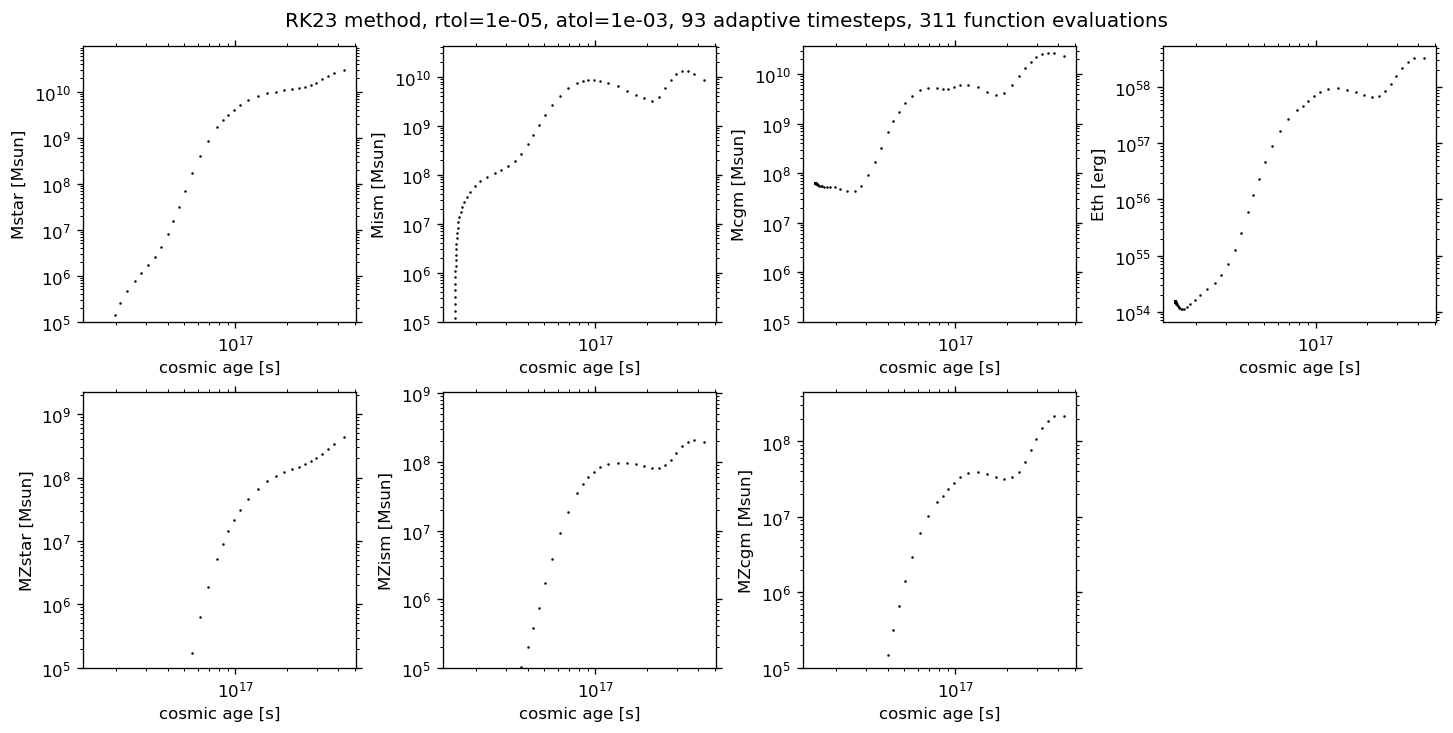

In [1333]:
labels = {0:'Mstar [Msun]',1:'Mism [Msun]',2:'Mcgm [Msun]',3:'Eth [erg]',4:'MZstar [Msun]',5:'MZism [Msun]',6:'MZcgm [Msun]'}
          
fig, axes = plt.subplots(nrows=2,ncols=4,figsize=(12,6),constrained_layout=True)
allax = np.ravel(axes)
allax[-1].axis('off')

for varnum in np.arange(7):
    
    allax[varnum].loglog(10**sol.t,10**sol.y[varnum],'k.',ms=3,mec='none')
    allax[varnum].set_xlabel('cosmic age [s]')
    allax[varnum].set_ylabel(labels[varnum])

fig.suptitle('%s method, rtol=%.0e, atol=%.0e, %i adaptive timesteps, %i function evaluations'%(ode_method,rtol,atol,len(sol.t),sol.nfev))

for axnum in [0,1,2,4,5,6]:
    allax[axnum].set_ylim(1e5,None)

# plt.savefig('solve_ivp_logarithmic_%s_%s_benchmark.png'%(halo_name,ode_method),bbox_inches='tight',dpi=150,facecolor='white')

# Now modify the above code to also solve for subhalo evolution

In [1334]:
### get row numbers of subhalos that still exist at z=0 and have Mpeak/Mvir_host(z=0) > fraction say 1e-4 (i.e., Mpeak > 1e8 for MW host)

# NOTE: change Dec 13 to instead use Msub(z=0)/Mvir_host(z=0) > 1e-4 as advocated by Nadler+23 since Mpeak-Msub relation is non-trivial
#       for example Mpeak~1e8 could've been at z~8 but if by z~0 it has ~1e7 that is not resolved (DM particle mass ~ 4e5 Msun)

# isubs = [i for i in range(1,len(r)) if r[i,-1]['ok'] == True and hist[i]['mpeak']/r[0,-1]['m'] > 1e-4]
# isubs = [i for i in range(1,len(r)) if r[i,-1]['ok'] == True and r[i,-1]['m']/r[0,-1]['m'] > 2e-4] # 2e-4 is a bit more conservative ---> 500 particles

# December 14 -- add condition to only model surviving satellites at z=0 that are within Rvir of host to ignore splashback subhalos...
isubs = [i for i in range(1,len(r)) if r[i,-1]['ok'] == True and r[i,-1]['m']/r[0,-1]['m'] > 2e-4 and np.sqrt(np.sum(r[i,-1]['x']**2)) <= r[0,-1]['rvir']]

# print number of selected subhalos, number of total subhalos, and most massive mpeak (LMC is logmpeak~11)
len(isubs), len(r), np.max(hist[isubs]['mpeak'])/1e11

(41, 439, 1.7242857472)

In [1335]:
# for those subhalos, create a list of redshifts when they first fell into the host halo
# for now, we will always treat subhalos as centrals before t_merge and as subhalos afterwards (this ignores flyby and splashback cases)

redshifts = 1/scale - 1
zmerge = np.array([-99] + [redshifts[hist[i]['merger_snap']] for i in isubs]) # prepending with z=-99 for host halo since it never becomes a subhalo

# similarly, find the earliest redshift when each subhalo first exists in the rockstar catalog
# prior to this, all subhalo ODEs will be set to 0 so we do not extrapolate interpolators and so subhalo's state variables do not change
# the [0]+isubs prepends the starting halo's redshift
zstart = np.array([redshifts[np.argmax(r[i,:]['ok'])] for i in [0]+isubs]) # argmax gives index of first occurrence of True

# zmerge, zstart


In [1336]:
### create parallelized function that returns list of interpolators for time series of needed properties for each subhalo

# access global arrays needed just once
Rvir_host = r[0,:]['rvir'] 
time_yr = time*1e9 # Gyr to yr

def interp_subhalo(i):
    """ 
    i is one element of isubs (the row to index the r and hist arrays) 
    """
    
    ok = r[i,:]['ok'] # time series of whether (sub)halo exists or not (True/False)    
    
    """ ratio dsub/Rvir """
    x = r[i,:]['x'] # subhalo position vector (x,y,z) relative to host halo center in proper kpc 
    
    # convert x to halo-centric distance in proper kpc by just doing sqrt(sum(x**2)) since (x,y,z) are halo-centric distances
    dsub = np.sqrt(np.sum(x[ok]**2,axis=1))
    
    # get Rvir(t) of host halo 
    # ok_host = r[0,:]['ok'] # we will IGNORE this one since host generally exists -- it's easier this way... 
    Rvir_host_ok = Rvir_host[ok] # just access Rvir at same snapshots where subhalo exists    
    
    # divide to get subhalo radial distance in units of host Rvir(t)
    rsub = dsub / Rvir_host_ok
    
    # smooth and interpolate -- for extrapolation, return boundary value (assuming at late times, subhalo will always end at rsub << 1)
    interp_rsub_savgolay = InterpolatedUnivariateSpline(time[ok], savgol_filter(rsub, window_length=5, polyorder=4), k=3, ext=3) # proper kpc
    
    """ mass accretion history """
    Msub = r[i,ok]['m'] # Mvir(t) from rockstar at snapshots where halo exists / is "ok" -- for subhalos, this is Mbound 
    
    # at every snap, replace Mvir with Mpeak(<snap) with this list comprehension
    # subhalo mass loss phase: replace with Mpeak(>t) instead to prevent any mass increases (hence monotonic mass loss) 
    Mpeak = [Msub[0]] + [np.max(Msub[:isnap+1]) if isnap<hist[i]['merger_snap'] else np.max(Msub[isnap:]) for isnap in range(1,len(scale[ok]))]

    # now apply a gaussian filter to ensure monotonicity and that dMpeak/dt cannot switch sign
    Msmooth = 10**gaussian_filter1d(np.log10(Mpeak),10,mode='nearest')

    # now fit cubic spline to log(M/Msun) vs log(t/yr)
    interp_logMsmooth = InterpolatedUnivariateSpline(np.log(time_yr[ok]),np.log(Msmooth),k=3,ext=3)

    # now take derivative of spline using its well-defined derivative function
    # this is dlog(M/Msun)/dlog(t/yr) -- to convert to dM/dt in Msun/yr, you multiply by Mhalo(t)/t
    interp_dlogM_dlogt = interp_logMsmooth.derivative()
    
    """ Rvir """
    interp_logRvir = InterpolatedUnivariateSpline(time[ok],gaussian_filter1d(np.log(r[i,ok]['rvir']),10,mode='nearest'),k=3,ext=3) # proper kpc

    """ Vvir """
    Vvir_rockstar = np.sqrt(G*r[i,ok]['m']*Msun_to_g / (r[i,ok]['rvir']*kpc_to_cm))*1e-5
    interp_logVvir = InterpolatedUnivariateSpline(time[ok],gaussian_filter1d(np.log(Vvir_rockstar),10,mode='nearest'),k=3,ext=3)

    """ cNFW """
    interp_logcNFW = InterpolatedUnivariateSpline(time[ok],gaussian_filter1d(np.log(r[i,ok]['cvir']),10,mode='nearest'),k=3,ext=3) # dimensionless    

    # return the interpolators in same order as for central
    return interp_dlogM_dlogt, interp_logMsmooth, interp_logRvir, interp_logVvir, interp_logcNFW, interp_rsub_savgolay



In [1337]:
# call in parallel to get stacked list of lists of interpolators for all subhalos with row indices in isubs

PoolProcesses = multiprocess.cpu_count()

tstart = timer()
pool = multiprocess.Pool(processes = PoolProcesses)

interpolators = pool.map(interp_subhalo,isubs)

# close pool processes to free memory
pool.close()
pool.join()

print('finished interpolating histories of %s subhalos in %s sec'%(len(isubs),timer()-tstart))

finished interpolating histories of 41 subhalos in 0.35040295898215845 sec


In [1338]:
# prepend the central halo's interpolators to the list of lists of subhalo interpolators 
# making this a numpy array to enable slicing 
tree_interpolators = np.array([(interp_dlogM_dlogt, interp_logMsmooth, interp_logRvir,interp_logVvir, interp_logcNFW, interp_rsub_savgolay)] + interpolators )


In [1983]:
"""
Set up ODE integrator function including subhalos (array-based operations)
"""

def integrator(logt, logy, parameters, interp_redshift, tree_interpolators, zmerge, zstart):
    """ 
    logt = log(current time in seconds)
    logy = 2D array of log(state variables) for host (0th row) and subhalos (other rows) at current time
    parameters = dictionary of model/runtime parameters
    interp_redshift = interpolator for mapping current time to redshift (faster to interpolate than re-evaluate cosmology functions)    
    tree_interpolators = list of lists of tree interpolators for host (0th index list) followed by subhalos
                         ---> the order of the interpolators is [logMAH,logMvir,logRvir,logVvir,logcNFW]
    zmerge = list of redshifts at which each subhalo first falls into host (before this, subhalos evolve as centrals, afterwards they evolve as satellites) 
    zstart = list of earliest redshifts at which each halo first appears in merger trees (before this, all ODEs should be 0 so halo does not evolve)
    """
    
    # Austen's approach: reshape flattened logy to have shape (N halos, 7 state variables)
    logy = logy.reshape(len(tree_interpolators), 7)
    
    # unpack the log10 state variables and raise to power 10 

    M_star = 10**logy[:,0]
    M_ism = 10**logy[:,1]
    M_cgm = 10**logy[:,2]
    Eth_cgm = 10**logy[:,3]
    MZ_star = 10**logy[:,4]
    MZ_ism = 10**logy[:,5]
    MZ_cgm = 10**logy[:,6]
    
    # also raise the log10(t/sec) to power of 10 and convert to Gyr for interpolation functions
    t_Gyr = 10**logt * s_to_yr * 1e-9 
    
    # unpack our SAM's free parameters
    alpha_n = parameters['alpha_n']
    alpha_T = parameters['alpha_T']
    tau_escape = parameters['tau_escape']
    f_recycle = parameters['f_recycle']
    e_wind_halo = parameters['e_wind_halo']
    yZ = parameters['yZ']
    etaM_A = parameters['etaM_A']
    etaM_alpha0 = parameters['etaM_alpha0']
    etaM_alphaz = parameters['etaM_alphaz']
    etaM_beta = parameters['etaM_beta']    
    tdep_A = parameters['tdep_A']
    tdep_alpha0 = parameters['tdep_alpha0']   
    tdep_alphaz = parameters['tdep_alphaz']   
    tdep_beta = parameters['tdep_beta']    
    etaE_A = parameters['etaE_A']
    etaE_alpha0 = parameters['etaE_alpha0']
    etaZ_A = parameters['etaZ_A']
    etaZ_alpha0 = parameters['etaZ_alpha0']
    etaZ_alphaz = parameters['etaZ_alphaz']
    etaZ_beta = parameters['etaZ_beta']    
    alpha_prev = parameters['alpha_prev'] 
    kappa_RP = parameters['kappa_RP']
    return_all = parameters['return_all']
    
    # interpolate from current time to current redshift (faster than doing cosmology calculation)
    redshift = interp_redshift(t_Gyr).item()
    
    # unpack tree_interpolators: every subhalo has its own set of interpolators -- this is all a list of lists
    interp_logMAH = tree_interpolators[:,0]
    interp_logMvir = tree_interpolators[:,1]    
    interp_logRvir = tree_interpolators[:,2]    
    interp_logVvir = tree_interpolators[:,3]    
    interp_logcNFW = tree_interpolators[:,4]    
    interp_rRatio = tree_interpolators[:,5]   
    
    # evaluate the interpolator functions for every subhalo at the current time using list comprehension
    logMAH = np.array([interp(np.log(t_Gyr*1e9)).item() for interp in interp_logMAH]) # dlogM/dlogt (this is slope)
    
    # Prevent negative MAH for subhalos even prior to zmerge
    logMAH = np.clip(logMAH,0,None)
    
    Mvir = np.exp([interp(np.log(t_Gyr*1e9)).item() for interp in interp_logMvir]) # Mvir in Msun
    Mdot_vir = logMAH * (Mvir/(t_Gyr*1e9)) # MAR in Msun/yr via dlnM/dlnt * (M/t)
    Rvir = np.exp([interp(t_Gyr).item() for interp in interp_logRvir]) # proper kpc -- note the input is t in Gyr, unlike log(t/yr) for Mvir and MAH
    Vvir = np.exp([interp(t_Gyr).item() for interp in interp_logVvir]) # proper km/s 
    NFW_c = np.exp([interp(t_Gyr).item() for interp in interp_logcNFW]) # dimensionless NFW halo concentration Rvir/Rs_klypin
    rRatio = np.array([interp(t_Gyr).item() for interp in interp_rRatio])
    # print('---------> logt=%s, t_Gyr=%s, redshift=%s'%(logt,t_Gyr,redshift))
    # print('logy=%s'%logy)        
    # print('logMAH=%s,Mvir=%s,Mdot_vir=%s,Rvir=%s,Vvir=%s,c=%s'%(logMAH,Mvir,Mdot_vir,Rvir,Vvir,NFW_c))

    ### NEW for subhalos with zmerge < current redshift, they are satellites and not allowed to accrete ISM gas, so set Mdot_cool=0 and Edot_cool=
    # this is accomplished by converting zmerge into 0 or 1 for each halo depending on whether its zmerge happened before current redshift (i.e., at higher z)
    satellite_flag = np.where(rRatio<1, 0, 1) # assigns 0 for halos that have already fallen into the host (i.e., are currently satellites)

    """ 
    everything that follows is now an array operation 
    i.e., same calculation for host halo and all its subhalos simultaneously unless otherwise noted/modified
    """
    
    # compute gas free-fall radius rff = radius of Vmax ~ 2.16*Rscale ~ 2.16 * Rvir/cNFW 
    rff = 2.16 * (Rvir / NFW_c) / Rvir # in units of Rvir
    
    # compute any other global halo quantities 
    Tvir = 35.9 * Vvir**2 # K 
    evir_halo = 3/2. * const_kB * Tvir / (0.59*const_mp) # erg/Msun  
    tdyn_halo = Rvir / (Vvir * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # analytic formula for NFW Vcirc(rff:=r/Rvir) rom Mo, van den Bosch & White eqn 11.26
    NFW_vcirc_num = np.log(1+NFW_c*rff) - NFW_c*rff/(1+NFW_c*rff)
    NFW_vcirc_den = rff*(np.log(1+NFW_c)-NFW_c/(1+NFW_c))
    NFW_vcirc = Vvir*np.sqrt(NFW_vcirc_num/NFW_vcirc_den) # km/s
    tdyn_ism = rff*Rvir / (NFW_vcirc * 1e5*cm_to_kpc / (s_to_yr*1e-9)) # Gyr
    
    # get SF and ISM wind scalings from FIRE 
    tdep_ism = get_tdep(Vvir,redshift,A=tdep_A,alpha0=tdep_alpha0,alphaz=tdep_alphaz,beta=tdep_beta) # Gyr 
    etaM_ism = get_etaM_ism(Vvir,redshift,A=etaM_A,alpha0=etaM_alpha0,alphaz=etaM_alphaz,beta=etaM_beta) # dimensionless
    etaE_ism = get_etaE_ism(Vvir,redshift,A=etaE_A,alpha0=etaE_alpha0,alphaz=0.0,beta=0.0) # dimensionless    
    etaZ_ism = get_etaZ_ism(Vvir,redshift,A=etaZ_A,alpha0=etaZ_alpha0,alphaz=etaZ_alphaz,beta=etaZ_beta) # dimensionless    

    # new FIRE Zdot/Mdot scalings for chemical evolution modeling
    Zin_halo = get_Zin_halo(Vvir,redshift) # dimensionless Zdot/Mdot (*not* normalized to Zsun)
    
    # compute log10 of CGM metallicity normalized to Zsun for cooling function
    log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
        
    ### compute Mdot_in_halo and Edot_in_halo terms 
    # first f_UV for UVB photoionization suppression of halo inflows
    Mfilt = m_filt(z=redshift)
    f_UV = collapse_fraction(Mvir,Mfilt)  
    if parameters['f_UV_override']: 
        f_UV[1:] = 1 # *= satellite_flag
    
    # f_prev due to SN wind shock heating 
    # in the future will add zeta=Edot_out_halo_previous / (evir_halo*Mdot_in_halo) here 
    
    # assume this gas accretion brings in specific energy = evir_halo
    # f_prev will be computed and multiply both of these inflow rates AFTER we compute the halo energy outflow rate below
    Mdot_in_halo = f_UV * f_b * Mdot_vir # Msun/yr
    Edot_in_halo = Mdot_in_halo * evir_halo / yr_to_s # erg/s 
        
    # ALSO apply this satellite flag to prevent any new subhalo accretion (or loss), i.e., Mdot_in_halo = 0 and Edot_in_halo = 0
    Mdot_in_halo *= satellite_flag
    Edot_in_halo *= satellite_flag
    
    ### compute Edot_cool and Mdot_cool terms
    # first get n0 for density profile and T0 for temperature profile (this can be done analytically)
    rarr = np.logspace(np.log10(0.1), np.log10(1.0), 100)    

    n0_val = analytic_n0(M_cgm, 0.1*Rvir, Rvir, alpha_n) # cm**-3
    T0_val = analytic_T0(Eth_cgm, 0.1*Rvir, Rvir, n0_val, alpha_n, alpha_T) # K
    
    # now construct density and temperature profiles
    # NOTE: this now has a list comprehension due to working with subhalos: it's a 2D array, where each row is radial profile of n(r) for each subhalo
    n_rarr = np.array([n0 * rarr**alpha_n for n0 in n0_val]) # cm**-3
    T_rarr = np.array([T0 * rarr**alpha_T for T0 in T0_val]) # K     

    ##### NEW FOR AUSTEN -- USE CIE SD93 COOLING FUNCTION -- this is just a scalar number, no longer an array, so easier/faster to work with
    # halo_coolfunc = 10**coolfunc_sd93(np.log10(T0_val),log_Zcgm).item() # erg*cm**3/s 
    halo_coolfunc = 10**rgi_sd93(list(zip(np.log10(T0_val),log_Zcgm)))
    # print('coolfunc=%s, T0_val=%s'%(halo_coolfunc,T0_val))
    
    # compute the Edot_cool integral in erg/s
    # NOTE: this needs to be a list comprehension since integration of radial profiles happens for each halo
    Edot_cool = np.array([trapz(y=4*np.pi*(rarr*Rvir[i]*kpc_to_cm)**2*(n_rarr[i])**2*halo_coolfunc[i],x=rarr*Rvir[i]*kpc_to_cm) 
                          for i in range(len(Rvir))])
    
    # limit catastrophic cooling by taking minimum of Edot_cool and Eth/tff since CGM cannot lose energy faster than grav collapse (radiating away grav PE)
    # NOTE: added axis=0 for np.min over subhalo array
    Edot_cool = np.min([Edot_cool,Eth_cgm/(tdyn_halo*1e9*yr_to_s)], axis=0)
    
    # compute an effective tcool as Energy_cgm / Edot_cool
    tcool_eff = (Eth_cgm / Edot_cool)*s_to_yr*1e-9 # Gyr    

    # compute effective free-fall time at pre-defined radius rff 
    tff_eff = (rff*Rvir*kpc_to_cm*1e-5 / NFW_vcirc)*s_to_yr*1e-9 # Gyr        

    # compute Mdot_cool as M_cgm / t_accrete where t_accrete = tcool,eff + tff,eff
    t_accrete = tcool_eff + tff_eff # Gyr
    Mdot_cool = M_cgm / (t_accrete*1e9) # Msun/yr        
    
    # and then multiplying the Mdot_cool and Edot_cool by this flag to zero it out (for current satellites) or keep it as-is (for current centrals)
    Edot_cool *= satellite_flag
    Mdot_cool *= satellite_flag
    
#     # print('Mdot_cool=%.1e, Edot_cool=%.1e, Eth/tdyn_halo=%.1e'%(Mdot_cool,Edot_cool,Eth_cgm/(tdyn_halo*1e9*yr_to_s)))
#     ### ram pressure stripping terms

    # define array to calculate how much mass and energy is stripped by RP 
    m_strip_RP_cgm = np.zeros(len(tree_interpolators))
    m_strip_RP_ism = np.zeros(len(tree_interpolators))
    E_strip_RP_cgm = np.zeros(len(tree_interpolators))
    
    r_RP_arr = np.zeros(len(tree_interpolators))
    rRatio_arr = np.zeros(len(tree_interpolators))
    
    # r_disk fixed at 1 kpc 
    r_disk_ism = np.ones(len(tree_interpolators)) 

    # check if any of the satellite flags is 0 (a satellite) to do calculations 
    if sum(satellite_flag == 0) > 0: 
        # get CGM parent density at satellite position ... Msun / kpc^3 
        rho_rRatio = 0.59 * const_mp * n0_r(n0_val[satellite_flag == 0], rRatio[satellite_flag == 0] * Rvir[0], Rvir[0], alpha_n) * cm_to_kpc**-3
        
        # using the L-Galaxies formula 
        r_RP_cgm = (kappa_RP * const.G.to('kpc**3 / (Msun * s**2)').value*((Mvir + M_cgm + M_ism) * M_cgm)[satellite_flag == 0]  / (4*np.pi * Rvir[satellite_flag == 0]**2 * rho_rRatio * (Vvir[satellite_flag == 0] * 1e3 * 1e2 * cm_to_kpc)**2))**0.5
        r_RP_cgm[r_RP_cgm / Rvir[satellite_flag == 0] < 0.1] = 0.1*Rvir[satellite_flag == 0][r_RP_cgm / Rvir[satellite_flag == 0] < 0.1]  
        r_RP_cgm[r_RP_cgm / Rvir[satellite_flag == 0] > 1] = 1*Rvir[satellite_flag == 0][r_RP_cgm / Rvir[satellite_flag == 0] > 1]  
        
        # calculate the mass that will be stripped away ... Msun 
        m_strip_RP_cgm[satellite_flag == 0] = mCGM_r1_r2(n0_val[satellite_flag == 0], r_RP_cgm, Rvir[satellite_flag == 0], alpha_n)
        
        # calculate the energy of the CGM that will be stripped away 
        E_strip_RP_cgm[satellite_flag == 0] = Ecgm_r1_r2(T0_val[satellite_flag == 0], r_RP_cgm, Rvir[satellite_flag == 0], n0_val[satellite_flag == 0], alpha_n, alpha_T)
        
        r_RP_arr[satellite_flag == 0] = r_RP_cgm
        rRatio_arr[satellite_flag == 0] = r_RP_cgm/ Rvir[satellite_flag == 0]

        r_RP_ism = (kappa_RP * const.G.to('kpc**3 / (Msun * s**2)').value*((Mvir + M_cgm + M_ism) * M_ism)[satellite_flag == 0] / (4*np.pi * Rvir[satellite_flag == 0] * 1 * rho_rRatio * (Vvir[satellite_flag == 0] * 1e3 * 1e2 * cm_to_kpc)**2) )**0.5
#         # any radii less than 1 parsec is set to 0 so entire ISM will be stripped ...  

        r_RP_ism[r_RP_ism < 1e-3] = 0 
        r_RP_ism[r_RP_ism > 1] = 1
#         # linear ratio placeholder 
#         m_strip_RP_ism[satellite_flag == 0] = M_ism[satellite_flag == 0] * ((r_disk_ism[satellite_flag == 0] - r_RP_ism) / r_disk_ism[satellite_flag == 0])

    # speed of sound in isothermal CGM, given in m / s turned into kpc / s
    c_s = (((5 / 3) * const.k_B.value * T0_val) / (0.59 * const.m_p.value))**0.5 * (100 * cm_to_kpc)
    # sound crossing time converted from s to yr 
    t_crossing = Rvir / c_s * s_to_yr
     
    # negative for satellites because it is an outflow  
    Mdot_RP_cgm = m_strip_RP_cgm / t_crossing # Msun / yr
    # if CGM mass < 1 Msun, don't apply RP stripping ... 
    Mdot_RP_cgm[M_cgm < 1] = 0
    
    Edot_RP_cgm = E_strip_RP_cgm / (t_crossing * yr_to_s) # ergs / s 
    Edot_RP_cgm[M_cgm < 1] = 0
    
    Mdot_RP_ism = m_strip_RP_ism / t_crossing
    Mdot_RP_ism[M_ism < 1] = 0
        
    ### compute SFR term
    Mdot_sfr = M_ism / (tdep_ism*1e9) # Msun/yr
    if parameters['Mdot_sfr_override']: 
        Mdot_sfr *= satellite_flag
    
    ### compute Mdot_wind and Edot_wind terms
    Mdot_wind = etaM_ism * Mdot_sfr # Msun/yr
    Mdot_wind[satellite_flag == 0 ] = 0 
    # March 2023 -- switch from parameterized vB back to parameterized etaE for computing Edot_wind 
    Edot_wind = etaE_ism * ((1e51/100.) * (Mdot_sfr/yr_to_s)) # erg/s
    
    ### compute Edot_out_halo and Mdot_out_halo terms 
    Ebind_cgm = evir_halo * M_cgm # erg
    Delta_Ecgm = Eth_cgm - Ebind_cgm # erg
    Edot_out_halo = np.maximum(0.0,Delta_Ecgm) / (tau_escape*tdyn_halo*1e9*yr_to_s) # erg/s; NOTE: switched to np.maximum to take axis=0 by default
    Mdot_out_halo = (Edot_out_halo/s_to_yr) / (e_wind_halo*(Eth_cgm/M_cgm)) # Msun/yr
    
    ### Go back and compute f_prev to reduce Mdot_in_halo and Edot_in_halo due to preventative feedback 
    # f_prev = np.min([1.0,kappa_heat * (Edot_out_halo / Edot_in_halo)])
    
    ### Nov 14 2022 -- parameterized fthermal_wind, fthermal_accretion, fprev
    f_prev = get_fprev(Vvir)#,redshift)
    
    # Carr+23/Pandya+20 style version where f_prev depends on ratio of Edot_out_halo and Edot_in_halo in the absence of preventative feedback
    # f_prev = np.min([alpha_prev * Edot_in_halo/Edot_out_halo, 1.0])
    
    Mdot_in_halo *= f_prev 
    Edot_in_halo *= f_prev 
        
    ##### New chemical evolution MZdot's 
    Zcgm = MZ_cgm / M_cgm # metal mass fraction of CGM (not normalized to solar and not log10)
    Zism = MZ_ism / M_ism # metal mass fraction of ISM     
    
    MZdot_sfr = Zism*(1.0-f_recycle)*Mdot_sfr # new long-lived stellar mass has same metallicity as ISM
    MZdot_cool = Zcgm*Mdot_cool # metal inflow rate from CGM to ISM
    MZdot_yield = yZ*Mdot_sfr # new metal mass produced by both short- and long-lived stars 
    MZdot_wind = Zism*Mdot_wind + etaZ_ism*MZdot_yield # metal outflow rate of ISM wind
    MZdot_in_halo = Zin_halo*Mdot_in_halo # metal inflow rate into CGM from cosmic accretion
    MZdot_out_halo = Zcgm*Mdot_out_halo # metal outflow rate from overpressurized halo
    MZdot_RP_cgm = Zcgm*Mdot_RP_cgm # metal outflow rate from sat CGM to host CGM from RP stripping 
    MZdot_RP_ism = Zism*Mdot_RP_ism # metal outflow rate from sat ISM to host CGM from RP Stripping

    
    ### Finally combine and return the total derivatives for the state variables (in the same order as y)
    # FIRST: since the time array (hence dt) will be in sec, convert all of these to Msun/s and erg/s
    Mdot_sfr_longlived = (1.0-f_recycle)*Mdot_sfr / yr_to_s # Msun/s
    np.logical_and(satellite_flag == 0, Mdot_RP_cgm > 0)
    Mdot_ism = (Mdot_cool - (1.0-f_recycle)*Mdot_sfr - Mdot_wind - Mdot_RP_ism) / yr_to_s # Msun/s 
#     Mdot_ism[np.logical_and(satellite_flag == 0, M_ism <= 1)] = 0
    # satellites under going RP will not be able to hold onto their own winds so add them to host
    Mdot_wind[0] += sum(Mdot_wind[np.logical_and(satellite_flag == 0, Mdot_RP_cgm > 0)])
    Mdot_wind[Mdot_RP_cgm > 0] = 0
    Mdot_cgm = (Mdot_in_halo - Mdot_cool + Mdot_wind - Mdot_out_halo - Mdot_RP_cgm) / yr_to_s # Msun/s 
    # transfer stripped mass to host 
    Mdot_cgm[0] += sum(Mdot_RP_cgm[np.logical_and(satellite_flag == 0, Mdot_RP_cgm > 0)]) / yr_to_s
    # any sat with a low mass CGM should not lose more to avoid breaking integrator 
    Mdot_cgm[M_cgm <= 1] = 0 
    
    Edot_cgm_th = Edot_in_halo - Edot_cool + Edot_wind - Edot_out_halo - Edot_RP_cgm # erg/s
    # transfer stripped mass energy to host 
    Edot_cgm_th[0] += sum(Edot_RP_cgm[np.logical_and(satellite_flag == 0, Mdot_RP_cgm > 0)])
    Edot_cgm_th[M_cgm <= 1] = 0 
        
    MZdot_star = MZdot_sfr / yr_to_s # Msun/s
    MZdot_ism = (MZdot_cool + MZdot_yield - MZdot_sfr - MZdot_wind - MZdot_RP_ism) / yr_to_s # Msun/s
    MZdot_cgm = (MZdot_in_halo - MZdot_cool + MZdot_wind - MZdot_out_halo - MZdot_RP_cgm) / yr_to_s # Msun/s 
    # transfer stripped CGM metals from sats to host 
    MZdot_cgm[0] += sum(MZdot_cgm[np.logical_and(satellite_flag == 0, Mdot_RP_cgm > 0)]) / yr_to_s
    MZdot_cgm[M_cgm <= 1] = 0 
    
    # NEW: at high-redshift, check which subhalos actually exist yet, and only let the state variables change/evolve for those existing subhalos
    # this is accomplished similarly to zmerge above: translate zstart array to 0 or 1 based on whether each subhalo's main branch has already started
    # then multiply total ODEs by this binary flag array to zero out (for subhalos that don't exist yet) or keep calculations as-is (for existing subhalos)
    early_flag = np.where(zstart<redshift,0,1) # assigns 0 for subhalos that start at a lower redshift than current redshift
    Mdot_sfr_longlived *= early_flag
    Mdot_ism *= early_flag
    Mdot_cgm *= early_flag # * satellite_flag
    Edot_cgm_th *= early_flag # * satellite_flag
    MZdot_star *= early_flag
    MZdot_ism *= early_flag
    MZdot_cgm *= early_flag # * satellite_flag
    
    # SECOND: since we are integrating log(state_variable) AND log(time), multiply RHS by 10**t[sec] / 10**state_variable
    #         thus these all become dimensionless logarithmic derivatives dlogX/dlogt
    # NOTE: for non-existing subhalos, these will all still be dlogX/dlogt = 0 aka zero change in logarithmic value of state variables 
    Mdot_sfr_longlived *= 10**logt / M_star 
    Mdot_ism *= 10**logt / M_ism 
    Mdot_cgm *= 10**logt / M_cgm
    Edot_cgm_th *= 10**logt / Eth_cgm
    MZdot_star *= 10**logt / MZ_star
    MZdot_ism *= 10**logt / MZ_ism
    MZdot_cgm *= 10**logt / MZ_cgm    
    
#     print('---------> logt=%s, t_Gyr=%s, redshift=%s'%(logt,t_Gyr,redshift))
    
#     print('M_star=%s,M_ism=%s,M_cgm=%s,Eth_cgm=%s,Ekin_cgm=%s,MZ_star=%s,MZ_ism=%s,MZ_cgm=%s'%(logy[0],logy[1],logy[2],logy[3],logy[4],logy[5],logy[6],logy[7]))    
    
#     print('Mdot_sfr_longlived=%s,Mdot_ism=%s,Mdot_cgm=%s,Edot_cgm_th=%s,T0=%s,MZdot_star=%s,MZdot_ism=%s,MZdot_cgm=%s'%(Mdot_sfr_longlived,Mdot_ism,
#                                                                                                                   Mdot_cgm,Edot_cgm_th,T0_val,
#                                                                                                                   MZdot_star,MZdot_ism,MZdot_cgm))
    
#     print('Mdot_in_halo=%s,Mdot_cool=%s,Mdot_wind=%s,Mdot_out_halo=%s'%(Mdot_in_halo,Mdot_cool,Mdot_wind,Mdot_out_halo))
#     print('Edot_in_halo=%s,Edot_cool=%s,Edot_wind=%s,Edot_out_halo=%s'%(Edot_in_halo,Edot_cool,Edot_wind,Edot_out_halo))    
    
#     print('T0=%s,Edot_in_halo_th=%s,Edot_diss=%s,Edot_cool=%s,Edot_wind_th=%s,Edot_out_halo_th=%s'%(T0_val,
#                                                                                                     Edot_in_halo_th*10**logt / Eth_cgm,
#                                                                                                     Edot_diss*10**logt / Eth_cgm,
#                                                                                                     Edot_cool*10**logt / Eth_cgm,
#                                                                                                     Edot_wind_th*10**logt / Eth_cgm,
#                                                                                                     Edot_out_halo_th*10**logt / Eth_cgm))

    print(Vvir)
    if return_all is True:
        return {'cosmic_age':t_Gyr, 'M_cgm': M_cgm, 
                'Mdot_in_halo':Mdot_in_halo, 'Mdot_cool' : Mdot_cool, 'Mdot_wind': Mdot_wind, 'Mdot_RP': Mdot_RP_cgm, 
                'Edot_in_halo':Edot_in_halo,'f_prev':f_prev,  'rRatio': rRatio, 'rRP_Ratio': rRatio_arr, 'm_strip_RP': m_strip_RP_cgm} 

    else: # Austen's approach: return flattened array of ODEs 
        return np.vstack([Mdot_sfr_longlived, Mdot_ism, Mdot_cgm, Edot_cgm_th, MZdot_star, MZdot_ism, MZdot_cgm]).T.flatten()

        

In [1984]:
### set integration times in log (t/sec)
z_init = 10.0 # previously z=8.98 
logt_init = np.log10(cosmo.age(z_init).value * 1e9 * yr_to_s) # Gyr to sec
z_final = 1/scale[-1] - 1
logt_final = np.log10(cosmo.age(z_final).value * 1e9 * yr_to_s) 

# output times at which to evaluate dense solution
logt_eval = np.linspace(logt_init,logt_final,1000)

### initial conditions for central and all subhalos 

# function that returns list of initial values for any halo given its interpolator functions
def ic_halo(logt_init,interp_logMvir,interp_logVvir):
    # just say initially the halo has Mcgm ~ half baryon budget (we dont know any better)
    Mcgm_init = 0.5*f_b*np.exp(interp_logMvir(np.log(10**logt_init*s_to_yr)))  # input is logt in yr
    Ecgm_init = (Mcgm_init*u.Msun * (np.exp(interp_logVvir(10**logt_init*s_to_yr*1e-9))*u.km/u.s)**2).to('erg').value # input is t in Gyr

    Mstar_init = 1. # arbitrary small number
    Mism_init = 1. # arbitrary small number
    Z_init = 1e-4 * 0.02 # assume initial metallicity is 1E-4/Zsun, multiply initial masses by this factor to get initial metal *mass*
    
    return np.log10([Mstar_init,Mism_init,Mcgm_init,Ecgm_init,Z_init*Mstar_init,Z_init*Mism_init,Z_init*Mcgm_init])
    
# use list comprehension to initialize for host halo and all subhalos at once
logy_init = np.array([ic_halo(logt_init,tree_interpolators[i][1],tree_interpolators[i][3]) for i in range(len(tree_interpolators))])


In [1985]:
parameters['Mdot_sfr_override'] = False
parameters['f_UV_override'] = False 
parameters['kappa_RP'] = 0
parameters['return_all'] = False

# # right now have to annoyingly copy each dict, cant do [parameters.copy] * 3 
# parameter_list = [parameters.copy(), parameters.copy(), parameters.copy()]
# parameter_list[1]['Mdot_sfr_override'] = True
# parameter_list[2]['f_UV_override'] = True

In [1986]:
parameters

{'return_all': False,
 'alpha_n': -1.5,
 'alpha_T': 0.0,
 'tau_escape': 1.0,
 'f_recycle': 0.4,
 'e_wind_halo': 1.0,
 'yZ': 0.02,
 'etaM_A': 0.1,
 'etaM_alpha0': -0.5,
 'etaM_alphaz': 0.0,
 'etaM_beta': 0.0,
 'tdep_A': 3.0,
 'tdep_alpha0': -3.0,
 'tdep_alphaz': 0.0,
 'tdep_beta': -0.7,
 'etaE_A': 0.3,
 'etaE_alpha0': -0.5,
 'etaZ_A': 0.5,
 'etaZ_alpha0': 0.0,
 'etaZ_alphaz': 0.0,
 'etaZ_beta': 0.0,
 'alpha_prev': 2.0,
 'kappa_RP': 0,
 'Mdot_sfr_override': False,
 'f_UV_override': False}

In [1987]:
tstart = timer()
# sol_arr = [solve_ivp(integrator,[logt_init,logt_final],logy_init.flatten(),dense_output=True,method=ode_method,
#                     atol=atol,rtol=rtol,args=(parameter_file,interp_redshift,tree_interpolators,zmerge,zstart)) for parameter_file in parameter_list]

sol_arr = [solve_ivp(integrator,[logt_init,logt_final],logy_init.flatten(),dense_output=True,method=ode_method,
                     atol=atol,rtol=rtol,args=(parameters,interp_redshift,tree_interpolators,zmerge,zstart))]

telapsed = timer()-tstart

print('\n',sol.message,'solve_ivp took %.3f seconds'%(telapsed),'\n')

[34.59574518 25.82471952 54.29797677 25.49208462  8.64763551 17.15451766
 25.15341205  9.38029782  9.50357498 11.31352475  7.81988393  9.78268021
 15.7308845  11.63783076 13.95284105 10.21432613 14.71615919  8.95707094
  9.612772    9.85449522 10.53626636  9.52429753  7.55852054 10.78747776
  7.38733004 20.95142596  8.50950304  5.15489361 14.40994231  8.6843319
  7.79645234 13.52149676  3.97855616  8.26434039  5.05772413  9.69287364
  8.08924501  8.62430851  9.01751881  8.10133678  8.44153991  5.29987062]
[34.59574528 25.82471967 54.29797684 25.49208474  8.64763554 17.15451772
 25.15341209  9.38029785  9.503575   11.31352478  7.81988393  9.78268028
 15.73088451 11.63783076 13.95284109 10.21432616 14.71615924  8.95707096
  9.61277205  9.85449528 10.53626639  9.52429753  7.55852057 10.78747778
  7.38733006 20.95142597  8.50950306  5.15489364 14.40994235  8.68433193
  7.79645236 13.52149679  3.97855616  8.26434039  5.05772413  9.69287366
  8.08924501  8.62430853  9.01751884  8.10133681  8

/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:22: RuntimeWarning: overflow encountered in power
  M_star = 10**logy[:,0]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:24: RuntimeWarning: overflow encountered in power
  M_cgm = 10**logy[:,2]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:25: RuntimeWarning: overflow encountered in power
  Eth_cgm = 10**logy[:,3]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:26: RuntimeWarning: overflow encountered in power
  MZ_star = 10**logy[:,4]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:28: RuntimeWarning: overflow encountered in power
  MZ_cgm = 10**logy[:,6]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:118: RuntimeWarning: invalid value encountered in divide
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipyke

[34.72102611 26.01379644 54.37827868 25.63998858  8.67986184 17.22499447
 25.2031317   9.41123078  9.52665562 11.3545564   7.81988393  9.86884891
 15.74114111 11.63783076 13.99342173 10.25030717 14.77583691  8.97945969
  9.6746466   9.92577602 10.57369568  9.52429753  7.60153133 10.80661604
  7.4144045  20.96046339  8.53637135  5.19041045 14.46201808  8.71844968
  7.83232948 13.5523439   3.97855616  8.26434039  5.05772413  9.71784542
  8.08924501  8.65467967  9.05841411  8.14436969  8.46589623  5.29987062]
[34.74483938 26.04990178 54.39352571 25.66793402  8.6859886  17.23848529
 25.21252559  9.41708919  9.53107115 11.36237594  7.81988393  9.88529946
 15.74311731 11.63783076 14.00113401 10.25715482 14.78715139  8.98370407
  9.68639387  9.93927513 10.58081526  9.52429753  7.60971023 10.81027887
  7.41956809 20.96216537  8.5414775   5.19719384 14.47187983  8.72495538
  7.83914985 13.55810583  3.97855616  8.26434039  5.05772413  9.72257859
  8.08924501  8.66045533  9.06616969  8.15256192  

/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:23: RuntimeWarning: overflow encountered in power
  M_ism = 10**logy[:,1]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:27: RuntimeWarning: overflow encountered in power
  MZ_ism = 10**logy[:,5]
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:267: RuntimeWarning: invalid value encountered in divide
  Zism = MZ_ism / M_ism # metal mass fraction of ISM
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:322: RuntimeWarning: invalid value encountered in multiply
  Mdot_ism *= 10**logt / M_ism
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:226: RuntimeWarning: invalid value encountered in divide
  Mdot_RP_cgm = m_strip_RP_cgm / t_crossing # Msun / yr
/var/folders/qp/ck5d01k170d866q0n0g9v9400000gn/T/ipykernel_13240/819864163.py:230: RuntimeWarning: invalid value encountered in divide
  Edot_RP_cgm

[35.95922812 27.9670199  55.17206199 27.02573815  8.99878434 17.96959244
 25.67368784  9.70668783  9.77110725 11.7711882   7.81988393 10.75378881
 15.85643185 11.63783076 14.39645626 10.60953001 15.35118364  9.19721615
 10.27848135 10.60435926 10.94623413  9.52429753  8.02887737 11.00722204
  7.6916657  21.04262868  8.80149913  5.55515376 14.95925598  9.06541615
  8.18733092 13.81187768  3.97855616  8.26434039  5.05772413  9.95765631
  8.08924501  8.95532657  9.45315416  8.57445769  8.71236263  5.32763432]
[35.98538133 28.0100723  55.18901545 27.05362826  9.00553143 17.98633561
 25.68336455  9.71272804  9.77665821 11.78024176  7.81988393 10.77312254
 15.8591685  11.63783076 14.40506812 10.61718302 15.3630421   9.20178867
 10.29106783 10.61814474 10.95416234  9.52429753  8.037971   11.01167432
  7.69774824 21.0442294   8.80709201  5.56309007 14.96942103  9.07293992
  8.19483956 13.816541    3.97855616  8.26434039  5.05772413  9.96257351
  8.08924501  8.96167026  9.46128974  8.58361345  

...

[136.22988852  68.85872194  44.98504493  26.41232163  16.38276197
  19.68993733  13.85465955  19.0696452   18.2829904   11.99131787
  14.11641611  11.22362621   9.76623352  13.70633757  10.73931588
  14.1862744   12.57673462  10.18222204  10.83463366   9.63104933
   9.08159696  10.14772121  11.8998991    9.62378252  11.87415461
  11.9944767    9.69573625   9.90585688   9.6374726    9.73375786
  10.08270409   9.99912985   9.69165218   9.64063205   9.64927683
   9.11563308   9.3295359    9.18942535   8.9182537    8.8346651
   8.78939587   8.37815978]
[136.23539363  68.82787362  44.96706129  26.39405533  16.37055847
  19.70539041  13.84886305  19.06564011  18.27950929  11.98499964
  14.11040084  11.22139181   9.76086887  13.69934383  10.73679439
  14.18215822  12.57117886  10.17702781  10.83062691   9.62877005
   9.07977498  10.1442671   11.89705243   9.61980582  11.87210345
  11.99258116   9.69283459   9.90045341   9.63415577   9.73138408
  10.08104901   9.9974036    9.68814723   9.63849

[136.38426677  67.92270753  44.45800948  25.88184272  16.02927046
  20.19479717  13.68721932  18.95162851  18.18020695  11.80548793
  13.93711631  11.15923487   9.61413938  13.50008562  10.66681756
  14.06558014  12.41464442  10.02653055  10.71685028   9.56534886
   9.02860765  10.04726699  11.81573      9.5048047   11.81385192
  11.93918527   9.61097139   9.74394525   9.54059671   9.66503841
  10.03384758   9.9488289    9.58688812   9.57781691   9.57951778
   9.0248908    9.2792512    9.13932913   8.87296797   8.77749957
   8.74819168   8.34368529]
[136.38514642  67.91690294  44.45485692  25.87869772  16.02718191
  20.19816139  13.68623209  18.95091912  18.17958706  11.80437171
  13.93602387  11.15885631   9.61326068  13.49884405  10.66639237
  14.06485757  12.41367956  10.02557718  10.71614333   9.56496256
   9.02829302  10.04667083  11.81522163   9.50407745  11.8134898
  11.93885601   9.61046545   9.74295421   9.54001919   9.66463235
  10.03355298   9.9485296    9.58624841   9.57743

[136.46410414  67.36947403  44.16360799  25.58940881  15.83555891
  20.52852773  13.59569616  18.88524219  18.12202247  11.70096848
  13.83397238  11.12420392   9.53360287  13.38375508  10.62752769
  13.99805586  12.32479222   9.93632112  10.65069021   9.52961002
   8.99933051   9.99182305  11.76798505   9.43605544  11.77994388
  11.90850046   9.56373015   9.65020256   9.48675766   9.62735181
  10.00619728   9.92094249   9.52644769   9.54245406   9.54038944
   8.97290635   9.25064374   9.11150303   8.84741201   8.74472703
   8.72522166   8.3244541 ]
[136.46429817  67.36805927  44.16287057  25.58867934  15.83507706
  20.5294153   13.59546855  18.88507559  18.12187594  11.70070592
  13.83371106  11.12411697   9.53340493  13.38346272  10.62743031
  13.99788659  12.3245678    9.93609213  10.65052411   9.52952134
   8.99925743   9.99168474  11.76786475   9.43588108  11.77985869
  11.90842375   9.56361178   9.64996468   9.48662303   9.62725799
  10.00612765   9.92087279   9.52629448   9.5423

[136.63434412  65.95203691  43.46149032  24.90049368  15.3845093
  21.50809731  13.38225434  18.72616846  17.98048819  11.44897427
  13.57765638  11.04311705   9.35330563  13.1033541   10.5370547
  13.83645797  12.11270198   9.71106017  10.49160908   9.44705959
   8.93020927   9.86133664  11.65168287   9.26488091  11.6981286
  11.83571496   9.45058633   9.41647788   9.35905007   9.53914173
   9.9389508    9.85477347   9.37624058   9.45699612   9.4464832
   8.84476326   9.18056168   9.04547689   8.78549347   8.66362382
   8.6703923    8.27855477]
[136.63509773  65.94476999  43.45807122  24.89716203  15.38235113
  21.51359888  13.38122961  18.72539251  17.97978819  11.44773624
  13.57636835  11.04273015   9.35246626  13.10197921  10.53662475
  13.83566847  12.11167731   9.70992646  10.49082941   9.44666674
   8.92987457   9.86070687  11.65110727   9.26402097  11.69772612
  11.83536151   9.45003186   9.41530319   9.3584304    9.53871721
   9.93861824   9.85445175   9.375487     9.45657537

[136.75732013  64.56534143  42.83974782  24.2968637   14.99834157
  22.65296361  13.19784722  18.58512277  17.85115504  11.2217604
  13.33601713  10.97394428   9.20642294  12.85202536  10.46045652
  13.6923284   11.92780796   9.49854535  10.34891542   9.37709243
   8.86953739   9.74762619  11.54534228   9.10391079  11.62410852
  11.77151399   9.34875662   9.196653     9.24669473   9.46258313
   9.8775164    9.7962003    9.23535799   9.37958081   9.36248814
   8.72577091   9.11577727   8.98727438   8.72922348   8.58756507
   8.62156234   8.23773049]
[136.75737031  64.5646602   42.83945701  24.29658205  14.99816397
  22.65357499  13.1977618   18.58505688  17.8510935   11.22165306
  13.33590033  10.97391246   9.20635687  12.85190725  10.46042143
  13.69226067  11.92772219   9.49844283  10.34884822   9.3770604
   8.86950907   9.74757337  11.5452917    9.10383324  11.62407346
  11.77148397   9.34870841   9.19654715   9.24664233   9.46254759
   9.87748718   9.79617284   9.2352902    9.379544

In [1981]:
def cosmic_evolution(sol):
    labels = {0:'Mstar [Msun]',1:'Mism [Msun]',2:'Mcgm [Msun]',3:'Eth [erg]',4:'MZstar [Msun]',5:'MZism [Msun]',6:'MZcgm [Msun]'}

    fig, axes = plt.subplots(nrows=2,ncols=4,figsize=(12,6),constrained_layout=True)
    allax = np.ravel(axes)
    allax[-1].axis('off')

    # reshape output for easier access
    sol_rs = sol.y.reshape(len(tree_interpolators),7,sol.y.shape[-1]) # (Nhalos, Nstatevars, Ntimes)

    for hnum in range(0, 11): # np.arange(len(tree_interpolators)):

        # access current halo's state variable vs time array
        hsol = sol_rs[hnum]

        if hnum == 0: 
            cstr, lw = 'k-', 2
        else: 
            cstr, lw = '-', 0.5

        for varnum in np.arange(7):

            allax[varnum].loglog(10**sol.t,10**hsol[varnum],cstr,lw=lw,mec='none')
            allax[varnum].set_xlabel('cosmic age [s]')
            allax[varnum].set_ylabel(labels[varnum])

    fig.suptitle('%s method, rtol=%.0e, atol=%.0e, %i adaptive timesteps, %i function evaluations, %i subhalos, %.2f sec'%(ode_method,rtol,atol,len(sol.t),
                                                                                                                           sol.nfev,len(tree_interpolators)-1,
                                                                                                                           telapsed))

    for axnum in [0,1,2,4,5,6]:
        allax[axnum].set_ylim(1e5,None)
        
    return axes 

    # plt.savefig('solve_ivp_logarithmic_%s_%s_benchmark.png'%(halo_name,ode_method),bbox_inches='tight',dpi=150,facecolor='white')

(5e-05, 1000000000.0)

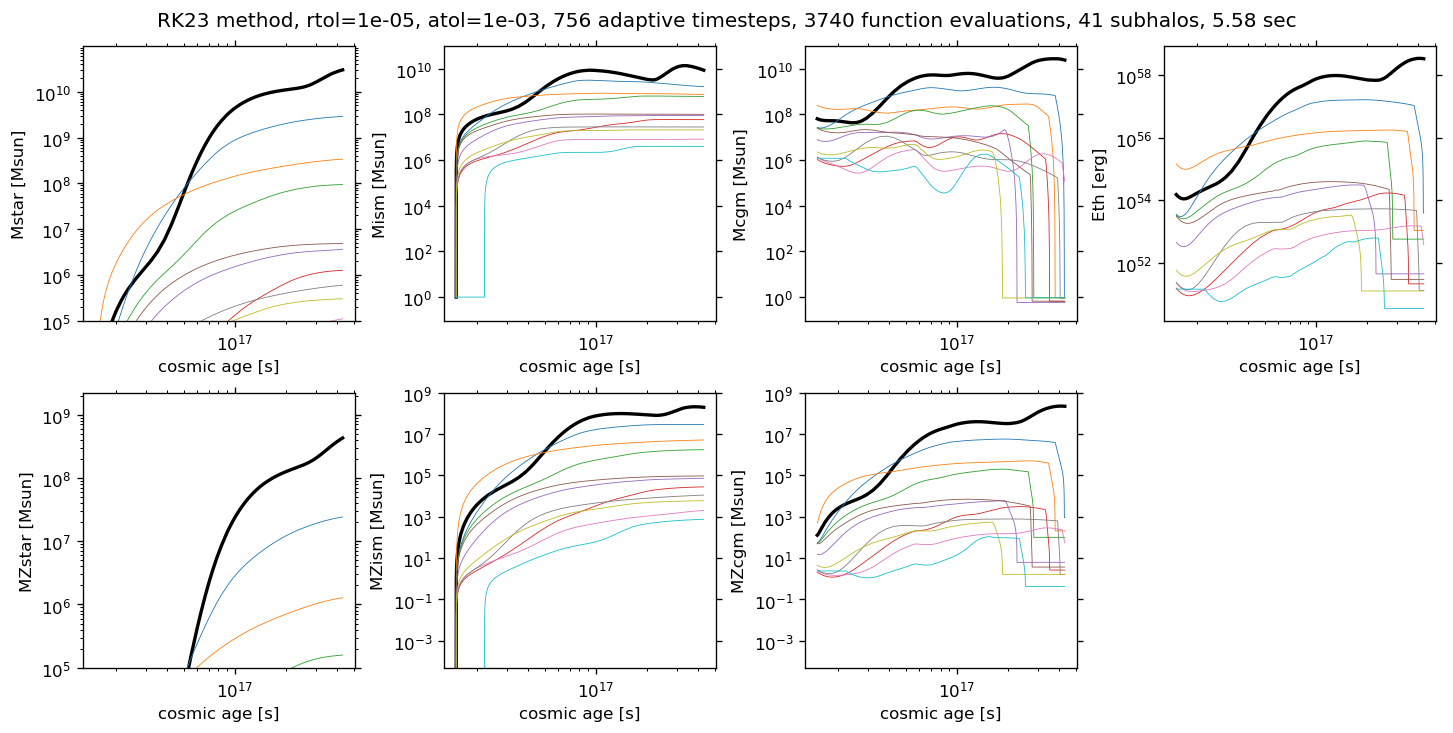

In [1982]:

axes = [cosmic_evolution(sol) for sol in sol_arr]


axes[0][0][1].set_ylim(0.9e-1, 1e11)
axes[0][0][2].set_ylim(0.9e-1, 1e11)
axes[0][1][2].set_ylim(0.5e-4, 1e9)
axes[0][1][1].set_ylim(0.5e-4, 1e9)

In [1954]:
dense_sol = sol_arr[0].sol(t_eval)

# set up output times at which to return dense_output -- let's say we want 1000 points between t_init and t_final
t_eval = logt_eval #  np.linspace(t_init,t_final,1000)

# first update parameters dict to return everything
parameters.update(return_all=True) 

# # store the output dict for each set of [time,state_variables] in the sol object
out_dicts = [integrator(logt_eval[tsol], dense_sol[:, tsol], parameters, interp_redshift, tree_interpolators, zmerge, zstart) for tsol in range(len(t_eval))]
# # use dict comprehension to combine all dicts so I have a list of each property vs time
comb_dict = {key: [d.get(key) for d in out_dicts] for key in set(out_dicts[0].keys())}

# finally revert parameters dict to set return_all back to False just in case... 
parameters.update(return_all=False) 

[148.34279086]
[152.37336787]
[158.64495239]
[165.77326138]
[173.65499916]
[182.39325764]
[192.09773525]
[202.86010339]
[214.7606437]
[228.08355045]
[243.14790165]
[260.27827908]
[279.80594306]
[302.03739982]
[327.15617508]
[356.20669696]
[392.22740567]
[440.36865032]
[509.43190094]
[619.46886979]
[819.11749871]
[1224.27041767]
[2246.78446038]
[6377.80757687]
[27640.42648998]
[  169.51705531 29671.49857615]
[  177.17597937 32133.62236213]
[  185.63470522 34918.25007303]
[  194.91352173 37924.6194653 ]
[  205.08807307 41059.35814505]
[  216.26242002 44235.64115575]
[  228.5501921  47372.22376628]
[  242.10224058 50421.35245036]
[  257.13981889 53386.07482709]
[  273.93156243 56273.01886237]
[  292.79994395 59087.76937182]
[  314.13424382 61835.09390491]
[  338.39835451 64518.88559952]
[  366.07749558 67140.69600711]
[  397.70427989 69700.78788214]
[  433.96680378 72199.0853278 ]
[  475.99998566 74635.22172382]
[  525.29902244 77008.58721619]
[  583.86083207 79320.23834088]
[  654.501848

[6.27717220e+03 4.15371180e+06 1.21126968e+06 5.51567940e+05
 2.53966139e+05 4.34871780e+05 1.26662060e+05 3.47165971e+05
 3.64026766e+03 1.62166493e+05 9.22762538e+04 1.16899293e+05
 1.48645449e+05 1.37593010e+05 1.10045856e+05 4.35019094e+04
 5.47448099e+04 4.79451849e+03 7.87661821e+04]
[   7525.05800091 4130505.0414464  1235517.69842193  546119.48427947
  251847.20943854  434464.32207114  127448.63275365  337815.56611989
    4758.65822256  162813.38540605  147036.81258416   92689.89084721
  115846.55706641  152616.46836224  136830.75182972  112312.85828301
   42861.3997288    53731.12271905   10819.65848822   78909.20314341]
[9.28429765e+03 4.09551842e+06 1.25785065e+06 1.38812800e+03
 5.39205842e+05 2.49047726e+05 4.33347556e+05 1.27865335e+05
 3.27824990e+05 6.36971613e+03 1.63930936e+05 1.42873574e+05
 9.47129316e+04 1.14791021e+05 1.56361647e+05 1.36098013e+05
 3.40833166e+03 1.14351435e+05 4.21942330e+04 5.26925204e+04
 2.78628380e+04 7.89908343e+04]
[1.18864908e+04 4.04844006

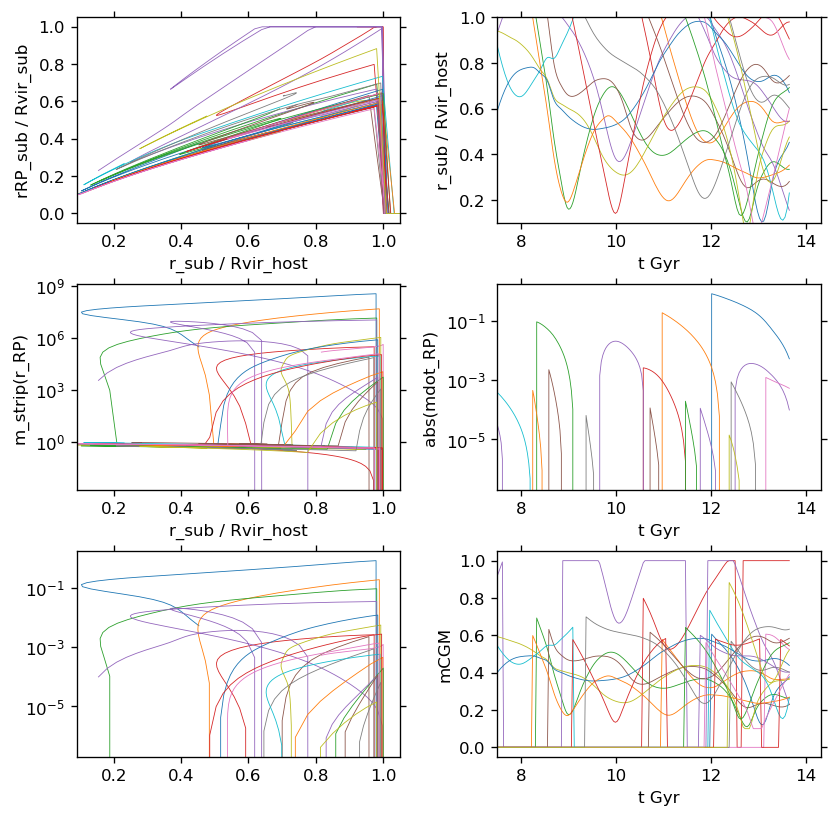

In [1955]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
plt.subplots_adjust(wspace=0.3, hspace = 0.3 )

#plt.plot(comb_dict['cosmic_age'], [comb_dict['rRatio'][i][1] for i in range(len(comb_dict['cosmic_age']))])
for j in range(1, 20):  #len(tree_interpolators)):# [1, 2, 3, 6, 7, 8 , 9 , ]:
    axes[0][0].plot([comb_dict['rRatio'][i][j] for i in range(len(comb_dict['cosmic_age']))], 
             [comb_dict['rRP_Ratio'][i][j] for i in range(len(comb_dict['cosmic_age']))], label='sat {}'.format(j), lw=0.5)
    axes[1][0].plot([comb_dict['rRatio'][i][j] for i in range(len(comb_dict['cosmic_age']))], 
             [comb_dict['m_strip_RP'][i][j] for i in range(len(comb_dict['cosmic_age']))], label='sat {}'.format(j), lw=0.5)
    axes[2][0].plot([comb_dict['rRatio'][i][j] for i in range(len(comb_dict['cosmic_age']))], 
             [abs(comb_dict['Mdot_RP'][i][j]) for i in range(len(comb_dict['cosmic_age']))], label='sat {}'.format(j), lw=0.5)
    axes[1][1].plot(comb_dict['cosmic_age'], 
             [abs(comb_dict['Mdot_RP'][i][j]) for i in range(len(comb_dict['cosmic_age']))], label='sat {}'.format(j), lw=0.5)
    axes[2][1].plot(comb_dict['cosmic_age'], 
             [abs(comb_dict['rRP_Ratio'][i][j]) for i in range(len(comb_dict['cosmic_age']))], label='sat {}'.format(j), lw=0.5)
    axes[0][1].plot(comb_dict['cosmic_age'], 
             [comb_dict['rRatio'][i][j] for i in range(len(comb_dict['cosmic_age']))], label='sat {}'.format(j), lw=0.5)

    
[axes[j][0].set_xlim(0.9e-1, 1.05) for j in range(0, 3)]
axes[0][0].set_xlabel('r_sub / Rvir_host')
axes[0][0].set_ylabel('rRP_sub / Rvir_sub')

axes[1][0].set_yscale('log')
axes[1][0].set_ylabel('m_strip(r_RP)')
axes[1][0].set_xlabel('r_sub / Rvir_host')

axes[1][1].set_ylabel('abs(mdot_RP)')
axes[1][1].set_xlabel('t Gyr')
axes[1][1].set_xlim(left=7.5)
axes[1][1].set_yscale('log')

axes[0][1].set_ylabel('r_sub / Rvir_host')
axes[0][1].set_xlabel('t Gyr')
axes[0][1].set_ylim(1e-1, 1.0)
axes[0][1].set_xlim(left=7.5)

axes[2][1].set_ylabel('mCGM')
axes[2][1].set_xlabel('t Gyr')
axes[2][1].set_xlim(left=7.5)

axes[2][0].set_yscale('log')

In [1937]:
#                # 'Mdot_in_halo':Mdot_in_halo, 'Mdot_cool' : Mdot_cool, 'Mdot_wind': Mdot_wind, 'Mdot_RP': Mdot_RP, 
# j = 1
# plt.plot(comb_dict['cosmic_age'], 
#              [(comb_dict['Mdot_RP'][i][j]) for i in range(len(comb_dict['cosmic_age']))], label='Mdot_RP'.format(j))
# plt.plot(comb_dict['cosmic_age'], 
#              [comb_dict['Mdot_in_halo'][i][j] for i in range(len(comb_dict['cosmic_age']))], label='Mdot_in_halo'.format(j))
# plt.plot(comb_dict['cosmic_age'], 
#              [comb_dict['Mdot_cool'][i][j] for i in range(len(comb_dict['cosmic_age']))], label='Mdot_cool'.format(j))
# plt.plot(comb_dict['cosmic_age'], 
#              [comb_dict['Mdot_wind'][i][j] for i in range(len(comb_dict['cosmic_age']))], label='Mdot_wind'.format(j))

# plt.legend()
# plt.xlabel('t Gyr')
# plt.xlim(10, 14)


In [1843]:
# Halo occupation fraction
# cannot do this until we model also disrupted/merged halos ??? 



In [1844]:
def z_0_scales(sol):
    sol_rs = sol.y.reshape(len(tree_interpolators),7,sol.y.shape[-1]) # (Nhalos, Nstatevars, Ntimes)

    ### plot subhalo mass function in terms of Mpeak and Msub(z=0), and satellite stellar mass function -- all in the usual CDF way

    # get list of mpeak and msub(z=0) for all subhalos we used (i.e., for indices in isubs)
    vals_mpeak = np.array([hist[i]['mpeak'] for i in isubs])
    vals_msub = np.array([r[i,-1]['m'] for i in isubs])

    # and get list of mstar from final step of ODE solutions for all of these (1:1 mapped) 
    vals_mstar = np.array([10**sol_rs[i][0][-1] for i in range(1,len(isubs))])
    
    # and mism as well 
    vals_mism = np.array([10**sol_rs[i][1][-1] for i in range(1,len(isubs))])

    # bin definitions for CDFs of Mpeak, Msub and Mstar 
    bins_mpeak = 10**np.linspace(8, 12, 100)
    bins_msub = 10**np.linspace(8, 12, 100)
    bins_mstar = 10**np.linspace(4, 10, 200)
    bins_mism = 10**np.linspace(1, 10, 200)

    # construct CDFs
    n_mpeak, _ = np.histogram(vals_mpeak,bins=bins_mpeak)
    N_mpeak = np.cumsum(n_mpeak[::-1])[::-1]

    n_msub, _ = np.histogram(vals_msub,bins=bins_msub)
    N_msub = np.cumsum(n_msub[::-1])[::-1]

    n_mstar, _ = np.histogram(vals_mstar,bins=bins_mstar)
    N_mstar = np.cumsum(n_mstar[::-1])[::-1]
    
    n_mism, _ = np.histogram(vals_mism,bins=bins_mism)
    N_mism = np.cumsum(n_mism[::-1])[::-1]

    # observed Mism CDF from McConnachie+12 (latest 2021 table from website)
    n_m12, _ = np.histogram(tm12['Mstar'][tm12['rratio_300'] <= 1],bins=bins_mstar)
    N_m12 = np.cumsum(n_m12[::-1])[::-1]

    n_dw20, _ = np.histogram(tdw20['Mstar'],bins=bins_mstar)
    N_dw20 = np.cumsum(n_dw20[::-1])[::-1]
    
    # observed Mism CDF from Putman+21
    n_p21_MW, _ = np.histogram(putman21['MHI'][putman21['in_MW']].astype(float), bins=bins_mism)
    N_p21_MW = np.cumsum(n_p21_MW[::-1])[::-1]
    
#     n_p21_M31, _ = np.histogram(putman21['MHI'][putman21['in_M31']].astype(float), bins=bins_mism)
#     N_p21_M31 = np.cumsum(n_p21_M31[::-1])[::-1]

    # bincenters for plotting
    bincenters_mpeak = (bins_mpeak[1:]+bins_mpeak[:-1])/2.
    bincenters_msub = (bins_msub[1:]+bins_msub[:-1])/2.
    bincenters_mstar = (bins_mstar[1:]+bins_mstar[:-1])/2.
    bincenters_mism = (bins_mism[1:]+bins_mism[:-1])/2.

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12,9), constrained_layout=True)
    axes = np.ravel(axes)

    axes[0].plot(bincenters_mpeak, N_mpeak,'k-')
    # axes[0].plot(np.sort(vals_mpeak),np.arange(len(vals_mpeak))[::-1],'m-') # empirical way without arbitrary histogram binning
    axes[0].set_xlabel(r'$M_{\rm peak}$ [M$_{\odot}$]',fontsize=16)
    axes[0].set_ylabel(r'$N(>M_{\rm peak})$',fontsize=16)

    axes[1].plot(bincenters_msub, N_msub,'k-')
    axes[1].set_xlabel(r'$M_{\rm sub}^{\rm z=0}$ [M$_{\odot}$]',fontsize=16)
    axes[1].set_ylabel(r'$N(>M_{\rm sub}^{\rm z=0})$',fontsize=16)

    
    ### radial distance distributions
    # this has nothing to do with our model right now since we don't have orphans
    # so this is just the positions of the surviving z=0 subhalos in units of host Rvir
    dsubs = np.array([np.sqrt(np.sum(r[i,-1]['x']**2)) for i in isubs]) / r[0,-1]['rvir']
    ### this reveals lots of splashback halos which are included in symlink catalogs by default
    # we can get rid of them by adding the < Rvir conditions when creating isubs list above 
    bins_dsub = np.linspace(0,1,10)
    _ = axes[2].hist(dsubs,bins=bins_dsub,histtype='step',lw=1.5,color='c', label='sapphire')
    _ = axes[2].hist(putman21['rratio'][putman21['in_MW']],bins=bins_dsub,histtype='step',lw=1.5,color='green', label='Obs. MW sats.\nPutman+21')
#     _ = axes[2].hist(putman21['rratio'][putman21['in_M31']],bins=bins_dsub,histtype='step',lw=1.5,color='orange', label='Obs. M31 sats.\nPutman+21')
    axes[2].set_xlabel(r'$d_{\rm sub}/R_{\rm vir}$ (z=0)',fontsize=16)
    axes[2].set_ylabel(r'$N_{\rm sub}$',fontsize=16) 
    axes[2].legend(loc='upper right')

    axes[3].plot(bincenters_mstar, N_mstar,'c-',label='Sapphire')
    # axes[2].plot(bincenters_mstar, N_m12, 'm-',label='McConnachie 2021') # includes also M31 and LG dwarfs, not just MW satellites
    axes[3].plot(bincenters_mstar, N_dw20, 'm-',label='Obs. MW sats.\nMcConnachie+12 (updated)')
    axes[3].set_xlabel(r'$M_{\rm *}$ [M$_{\odot}$]',fontsize=16)
    axes[3].set_ylabel(r'$N(>M_{\rm *})$',fontsize=16)
    axes[3].legend(loc='lower left')

    
    axes[6].plot(bincenters_mism, N_mism,'c-',label='Sapphire')
    axes[6].plot(bincenters_mism, N_p21_MW, 'green',label='Obs. MW sats.\nPutman+21')
#     axes[6].plot(bincenters_mism, N_p21_M31, 'orange',label='Obs. M31 sats.\nPutman+21')
    axes[6].set_xlabel(r'$M_{\rm ism}$ [M$_{\odot}$]',fontsize=16)
    axes[6].set_ylabel(r'$N(>M_{\rm ism})$',fontsize=16)
    axes[6].legend(loc='lower left')

    
    for hnum in np.arange(len(tree_interpolators)):

        # access current halo's state variable vs time array
        hsol = sol_rs[hnum]

        if hnum == 0: 
            cstr, ms, label = 'c*', 15, 'sapphire MW host'
        elif hnum == 1: 
            cstr, ms, label = 'co', 5, 'sapphire MW satellites'        
        else: 
            cstr, ms, label = 'co', 5, '__none__'

        axes[4].plot(hist[hnum]['mpeak'],10**hsol[0][-1],cstr,markersize=ms,alpha=0.5,label=label) # Mstar vs. Mpeak

        axes[5].plot(10**hsol[0][-1], np.log10(10**hsol[4][-1]/10**hsol[0][-1]/0.02), cstr, markersize=ms,alpha=0.5,label='__none__') # Zstar/Zsun vs. Mstar
        
#         axes[7].plot(hist[hnum]['mpeak'], 10**hsol[1][-1], cstr, markersize=ms,alpha=0.5,label=label, zorder=10) # Mism vs. Mpeak

        axes[8].plot(10**hsol[0][-1], (10**hsol[1][-1]), cstr, markersize=ms,alpha=0.5,label='__none__') # Mism vs. Mstar


    mpeak_arr = np.logspace(9.3,12) 
    mstar_b13 = 1e-8 * mpeak_arr**1.41 
    mstar_manual = 1e-20*mpeak_arr**2.5 
    axes[4].plot(mpeak_arr,mstar_manual,'c-',label=r'$M_*\propto M_{\rm peak}^{2.5}$')
    # axes[4].plot(mpeak_arr,mstar_b13,'m-',label=r'Behroozi+13 ')
    axes[4].legend(loc='upper left',fontsize=9)
    axes[4].set_xlabel(r'$M_{\rm peak}/M_{\odot}$',fontsize=16)
    axes[4].set_ylabel(r'$M_*/M_{\odot}$',fontsize=16) 
    axes[4].set_xscale('log')
    axes[4].set_yscale('log')

    # now plot the observed MW satellites' MZR assuming [Fe/H] := Z := [M/H] 
    tdw20_zmet = tdw20[(tdw20['Fe/H'] != 999) & (tdw20['Fe/H_err_low'] != 999) & (tdw20['Fe/H_err_high'] != 999)] 
    print(len(tdw20), len(tdw20_zmet))
    axes[5].errorbar(tdw20_zmet['Mstar'],tdw20_zmet['Fe/H'], yerr=[tdw20_zmet['Fe/H_err_high'],tdw20_zmet['Fe/H_err_low']],
                fmt='mo',markersize=3,capsize=3,label='McConnachie+12 (updated)')    
    axes[5].set_xlabel(r'$M_*/M_{\odot}$',fontsize=16)
    axes[5].set_ylabel(r'$\log Z_*/Z_{\odot}$',fontsize=16)
    axes[5].set_xscale('log')
    axes[5].legend(loc='lower right',fontsize=8) 
    

#     axes[7].set_xlabel(r'$M_{\rm peak}/M_{\odot}$',fontsize=16)
#     axes[7].set_ylabel(r'$ M_{\rm ism} / M_{\odot}$',fontsize=16)
#     axes[7].set_xscale('log')
#     axes[7].set_yscale('log')
#     axes[7].set_ylim(5e5, 5e9)
#     axes[7].legend(loc='upper left',fontsize=8)     

    
    axes[8].errorbar(putman21['Mstar'][putman21['in_MW']],
                     putman21['MHI'][putman21['in_MW']].astype('float'),
                     yerr=[putman21['e_MHI'][putman21['in_MW']].astype('float'),
                           putman21['e_MHI'][putman21['in_MW']].astype('float')],
                     markersize=3, capsize=3, fmt='o', c='green', alpha=0.5,
                     label='Obs. MW sats.\nPutman+21') 
    
#     axes[8].errorbar(putman21['Mstar'][putman21['in_M31']],
#                      putman21['MHI'][putman21['in_M31']].astype('float'),
#                      yerr=[putman21['e_MHI'][putman21['in_M31']].astype('float'),
#                            putman21['e_MHI'][putman21['in_M31']].astype('float')],
#                      markersize=3, capsize=3, fmt='o', c='orange', alpha=0.5,
#                      label='Obs. M31 sats.\nPutman+21') 

    axes[8].set_xlabel(r'$M_*/M_{\odot}$',fontsize=16)
    axes[8].set_ylabel(r'$\log M_{\rm ism} / M_{\odot}$',fontsize=16)
    axes[8].set_xscale('log')
    axes[8].set_yscale('log')
    axes[8].legend(loc='upper left',fontsize=8)   

    for axnum in [0,1,3, 6]:
        axes[axnum].set_xscale('log')
        axes[axnum].set_yscale('log')

        axes[axnum].set_ylim(0.5e0,7e1)

    fig.suptitle('%s: only includes subhalos that are still surviving at z=0'%sim_dir[sim_dir.find('SymphonyMilkyWay'):])



57 45


[None]

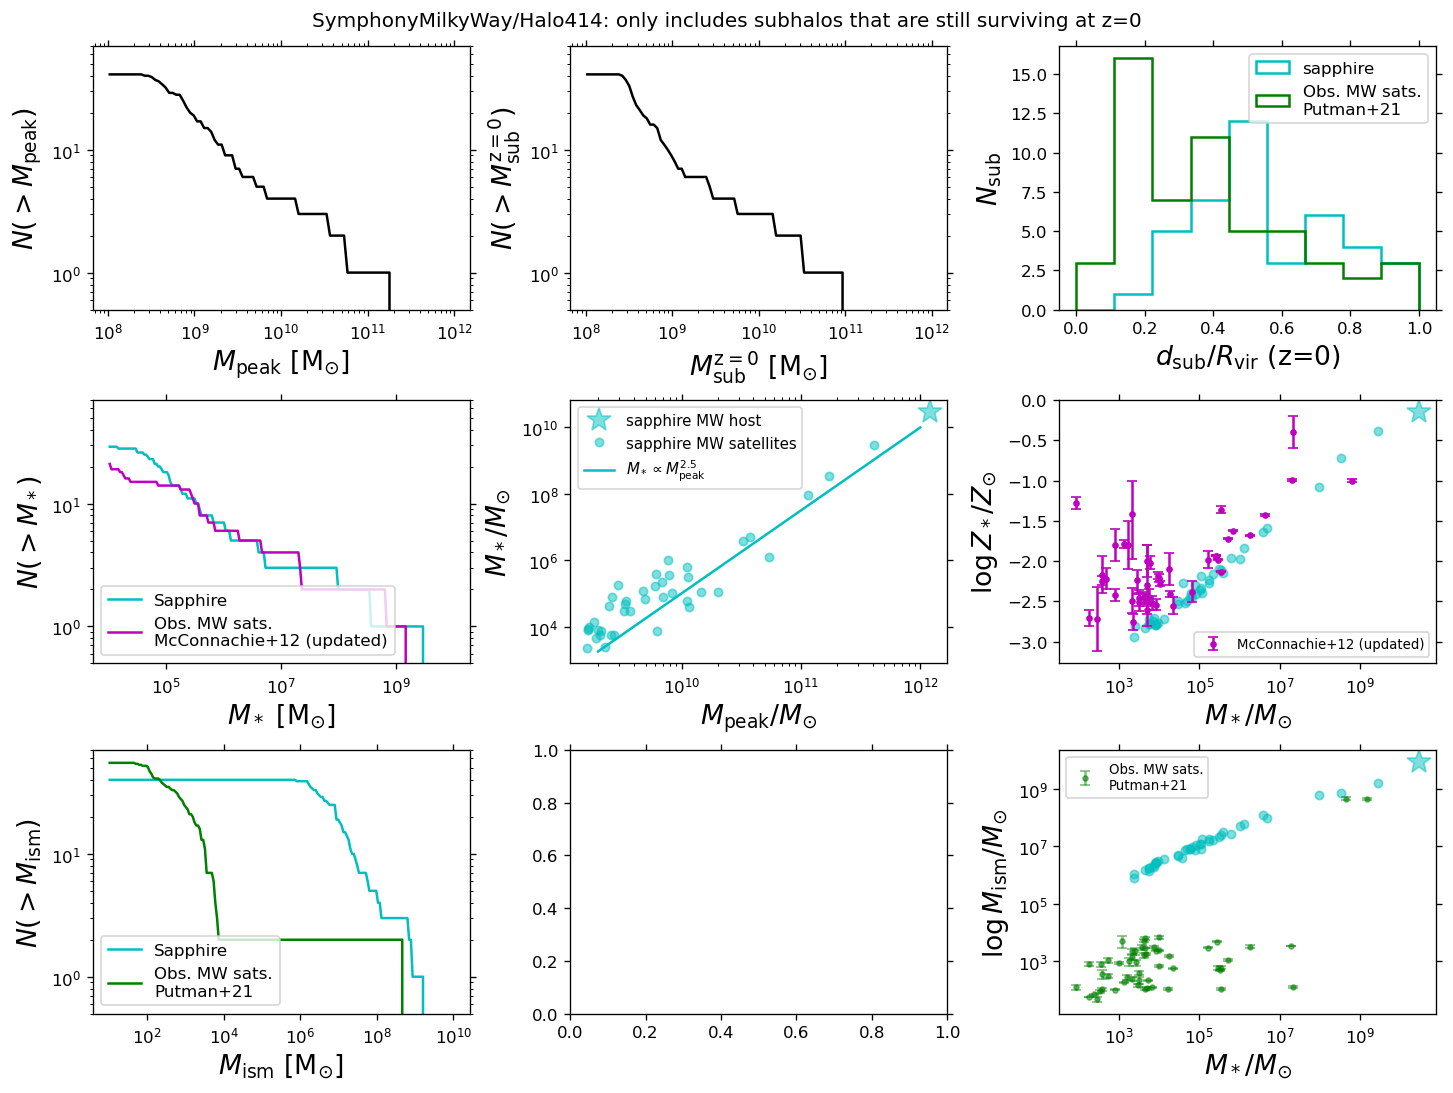

In [1845]:
[z_0_scales(sol) for sol in sol_arr]

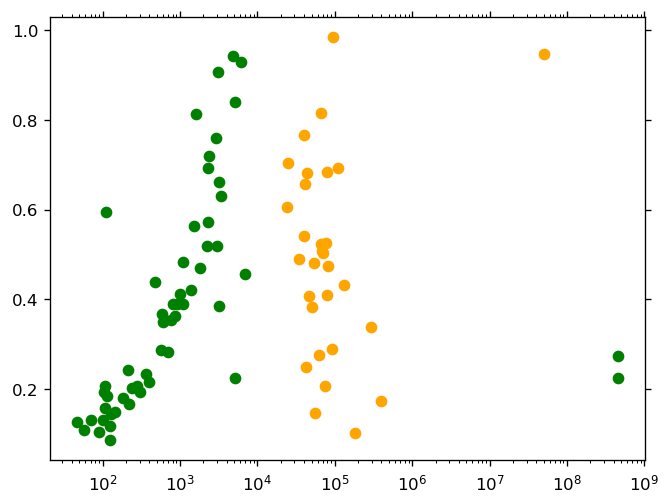

In [368]:
plt.scatter(putman21['MHI'][putman21['in_MW']].astype('float'), putman21['rratio'][putman21['in_MW']], c='green')
plt.scatter(putman21['MHI'][putman21['in_M31']].astype('float'), putman21['rratio'][putman21['in_M31']], c='orange')
plt.xscale('log')

Text(0, 0.5, '$d_{\\rm sub} / R_{\\rm vir}$')

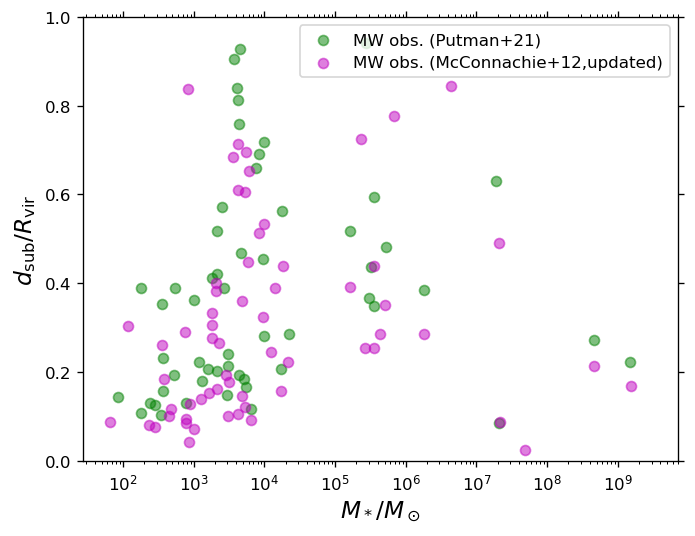

In [407]:
plt.scatter(putman21['Lv'][putman21['in_MW']].astype('float'), putman21['rratio'][putman21['in_MW']], 
            c='green', label='MW obs. (Putman+21)', alpha=0.5)
plt.scatter(tm12['Mstar'], tm12['rratio_300'], c='m', alpha=0.5, label='MW obs. (McConnachie+12,updated)')
# plt.scatter(tm12['Mstar'], tm12['rratio_224'], c='red')

plt.xscale('log')
plt.ylim(0, 1)

plt.legend()
plt.xlabel(r'$M_* / M_\odot$', fontsize=14)
plt.ylabel(r'$d_{\rm sub} / R_{\rm vir}$', fontsize=14)

In [374]:
tm12# .keys()


GalaxyName,RA,Dec,EB-V,dmod,dmod+,dmod-,vh,vh+,vh-,Vmag,Vmag+,Vmag-,PA,PA+,PA-,e=1-b/a,e+,e-,muVo,muVo+,muVo-,rh,rh+,rh-,sigma_s,sigma_s+,sigma_s-,vrot_s,vrot_s+,vrot_s-,MHI,sigma_g,sigma_g+,sigma_g-,vrot_g,vrot_g+,vrot_g-,[Fe/H],feh+,feh-,F,pmra,epmra+,epmra-,pmdec,epmdec+,epmdec-,References,M_V,L_V,Mstar,distance,rratio_300,rratio_224
str16,str10,str11,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,str53,float32,float32,float32,float32,float32,float32
*Bootes3,13:57:12.0,26:48:0.0,0.021,18.35,0.1,0.1,197.5,3.8,3.8,12.6,0.5,0.5,90.0,999.0,999.0,0.5,999.0,999.0,31.3,0.3,0.3,999.0,999.0,999.0,14.0,3.2,3.2,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.1,0.2,0.2,2,nan,nan,nan,nan,nan,nan,(14)(15)(99),-5.75,17060.818,17060.818,46.773525,0.15591174,0.20881037
*CanisMajor,7:12:35.0,-27:40:0.0,0.264,14.29,0.3,0.3,87.0,4.0,4.0,-0.1,0.8,0.8,123.0,999.0,999.0,999.0,999.0,999.0,24.0,0.6,0.6,999.0,999.0,999.0,20.0,3.0,3.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-0.5,0.2,0.2,4,nan,nan,nan,nan,nan,nan,(1)(2)(95)(176),-14.39,48752924.0,48752924.0,7.2110763,0.024036922,0.032192305
*Cetus2,1:17:52.8,-17:25:12.0,0.02,17.1,0.1,0.1,999.0,999.0,999.0,17.4,0.7,0.7,999.0,999.0,999.0,999.0,999.0,999.0,28.55,1.2,1.2,1.9,1.0,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.28,0.07,0.07,5,2.84,0.05,0.07,0.46,0.06,0.07,(232)(260)(266)(267),0.29999924,64.86349,64.86349,26.302685,0.087675616,0.1174227
*Columba1,5:31:26.4,-28:1:48.0,0.025,21.3,0.22,0.22,153.7,5.0,4.8,16.8,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,27.95,0.7,0.7,1.9,0.5,0.4,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,0.19,0.06,0.06,-0.36,0.06,0.06,(232)(248)(266)(267),-4.5,5395.1045,5395.1045,181.96999,0.6065666,0.812366
*Draco2,15:52:47.6,64:33:55.0,0.018,16.67,0.05,0.05,-342.5,1.1,1.2,14.0,0.8,0.8,76.0,22.0,32.0,0.23,0.15,0.15,25.62,1.3,1.3,3.0,0.7,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.7,0.1,0.1,5,1.08,0.07,0.07,0.91,0.08,0.08,(225)(259)(266)(267),-2.67,1000.0,1000.0,21.57745,0.071924835,0.0963279
*Eridanus3,2:22:45.5,-52:17:1.0,0.025,19.7,0.2,0.2,999.0,999.0,999.0,17.33,0.86,0.86,62.0,11.0,11.0,0.32,0.13,0.13,22.84,4.28,2.13,0.29,0.23,0.23,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,1.08,0.14,0.45,-0.49,0.17,0.13,(226)(227)(255)(266)(267),-2.3700008,758.5782,758.5782,87.096375,0.29032126,0.3888231
*Grus1,22:56:42.4,-50:9:48.0,0.008,20.4,0.2,0.2,-140.5,2.4,1.6,16.93,0.59,0.59,11.0,32.0,32.0,0.54,0.26,0.26,26.86,1.77,1.35,2.08,0.87,0.87,9.8,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.42,0.55,0.42,2,0.07,0.05,0.05,-0.29,0.06,0.07,(226)(252)(255)(266)(267),-3.4699993,2089.2947,2089.2947,120.226425,0.40075475,0.5367251
*Grus2,22:4:4.8,-46:26:24.0,0.016,18.62,0.21,0.21,-110.0,0.5,0.5,14.7,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,28.35,0.7,0.7,6.0,0.9,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.51,0.11,0.11,3,0.38,0.03,0.03,-1.46,0.04,0.04,(232)(262)(266)(267),-3.920001,3162.2812,3162.2812,52.966343,0.17655447,0.23645689
*Horologium1,2:55:31.7,-54:7:8.0,0.014,19.5,0.2,0.2,112.8,2.5,2.6,15.95,0.56,0.56,50.0,26.0,26.0,0.31,0.16,0.16,26.28,1.1,0.99,1.54,0.34,0.34,4.9,2.8,0.9,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.76,0.1,0.1,2,0.82,0.03,0.03,-0.61,0.03,0.03,(226)(227)(254)(255)(266)(267),-3.5500002,2249.0547,2249.0547,79.432846,0.26477614,0.35461092


In [390]:
tm12['Mstar'][tm12['rratio_300'] <= 1]

17060.818
48752924.0
64.86349
5395.1045
1000.0
758.5782
2089.2947
3162.2812
2249.0547
359.74915
855.0666
